# A Quantum Register Model for Correlated Market Reactions

### Author: Justin L. Oliver

### AI Disclaimer

I used generative AI to speed myself up on this project, mainly **ChatGPT** (OpenAI) and sometimes **Claude** (Anthropic) when a coding step was especially difficult. I cite both tools here as required for the final project. The big picture questions and what I wanted to learn are still fully mine. AI did not invent this project for me.

On the data side, ChatGPT helped me scrub the web, pull together two hundred events, draft scores for the five input channels, and build the CSV files I load below. I chose which topics matter for this study (technology shifts, regulation, macro shocks, and disasters) from my own research direction and what I already studied at UC Davis. Those topic choices and the labeling rules are mine. AI helped fill in rows, and I reviewed and adjusted scores when something looked off. I did not paste course handouts or private material verbatim into either tool.

ChatGPT and Claude also wrote or rewrote most of the code in this notebook. I stepped through it, ran it, and changed pieces when they did not match what I wanted. I can explain how the workflow operates throughout the project, not only read AI output back. The circuit is one place where I was picky. I adjusted gates by hand when I had a specific gate pattern in mind. The tuning pass that sets all the angles across the circuit was done with COBYLA because I ran out of time to build my own trainer. I wrote prompts in my own words and edited AI text and code before treating it as my submission.

I looked for market data APIs online. Many good feeds cost money, so I stayed with what I already had. If I keep going, the plan is to collect more data and improve how the circuit tracks the labels.

The whole thing has been super entertaining for me and I would love to dive deeper and explore more when I can.

### About

This work is a research exploration at the intersection of quantum computing and quantitative finance. The aim is to experiment with whether ideas and techniques from quantum programming coursework, together with AI-assisted coding and analysis tools, can be used to build and interpret a model that ingests event-like inputs in a form suited to near real time finance prediction. The emphasis is on understanding how the pieces fit together and where the assumptions limit the story, not on shipping a live trading product.

The notebook is written so the steps are easy to undeerstand. Someone should be able to see the code and circuit drawings. This is not a finished trading system and it is not a hardware showcase. The open question is whether a similar quantum style circuit can turn headline features into linked guesses for multiple tickers in a faster way than a fully classical models. For now everything stays inside software simulation only, so any claim that classical code is slower would still need to be explored. Everything runs as a quantum circuit simulated on a normal computer, not on a real quantum computer like IBM. The circuit is built to be low resource and small scale so limited as a nine qubit pattern. The training targets are simple up or down labels built from daily returns.

The project does not track dollars and does not score profit on a trade. A asset qubit measurment in this notebook only records whether price moved up or flat/down 5 days after the event. The model is only graded on whether its guess matches that up or down fact, not on making money. This is not the best financial experiment, however, the core circuit exploration and design is the true study.

### Circuit summary

The experiment uses nine qubits on a simulator, but they are not nine copies of the same thing. The first 5 qubits are inputs that form an event register: each one stands for a different slice of the headline (overall intensity, macro, disruption, technology, regulation). Four other qubits form an asset register where each one is a qubit we eventually read out as “1=up” or “0=down/flat” for USD, Gold, the S&P 500, and Bitcoin. These assets were intentionally chosen since they are 4 completley different markets. 

Each event row contributes five numbers from the data (q0 through q4). Those numbers do not train the whole circuit; they only set the first rotations on the event qubits. A rotation around the Y axis (RY) tilts each qubit from |0⟩ toward |1⟩ by an amount that depends on the score. Stronger headlines push the state further along that axis before any coupling happens.

A separate list of 34 trained angles (theta) controls everything that links wires together and shapes the final readout. Part of theta goes into controlled rotations (CRY gates) from the headline register into the asset register. It basically checks “if this news qubit is active, nudge that asset qubit.” Another part goes into RZZ gates between the pairs of different asset qubits. RZZ does not flip a qubit by itself as it entangles two assets so their up/down outcomes are correlated. For example, when Crypto is more likely to read “up,” Gold or the index may be pulled the same or opposite way, depending on what training learned. Finally, readout RY gates on the four asset wires set how each asset is biased right before measurement. After measurement, we get a four-bit string (sixteen possibilities), which we compare to realized up/down labels over the next five trading days.




# Imports

In [135]:
# =============================================================================
# Environment and module loading 
# =============================================================================
from pathlib import Path
import json
import sys
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# --- Repository layout (notebook cwd = project root) ---
ROOT = Path.cwd()
SRC = ROOT / "src"
DATA_DIR = ROOT / "data"
MODELS_DIR = ROOT / "models"
FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)  # notebook figures/ (PNGs from savefig below)

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))


def _load_src_module(name: str, rel_path: str):
    """Load a src/*.py module by file path (works in Jupyter without pip install)."""
    """Load src/*.py by path so Jupyter reload picks up edits."""
    path = SRC / rel_path
    spec = importlib.util.spec_from_file_location(name, path)
    if spec is None or spec.loader is None:
        raise ImportError(f"Cannot load {name} from {path}")
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod


_qmm = _load_src_module("quantum_market_model", "quantum_market_model.py")  # 9-qubit PQC: build_circuit, predict_one
get_qubit_map = _qmm.get_qubit_map
count_parameters = _qmm.count_parameters
build_circuit = _qmm.build_circuit
draw_circuit_mpl = _qmm.draw_circuit_mpl
predict_one = _qmm.predict_one

_eu = _load_src_module("evaluation_utils", "evaluation_utils.py")  # load training_events.csv
load_training_events = _eu.load_training_events

_rh = _load_src_module("run_holdout_eval", "run_holdout_eval.py")  # holdout tables + Aer shot marginals
run_holdout_eval = _rh.run_holdout_eval
marginal_probs_from_aer_shots = _rh.marginal_probs_from_aer_shots
holdout_event_shot_seed = _rh.holdout_event_shot_seed

ASSET_ORDER = ["USD", "Gold", "SP500", "BTC"]
LABEL_TO_COL = {
    "USD": "usd_up",
    "Gold": "gold_up",
    "SP500": "sp500_up",
    "BTC": "btc_up",
}
FEATURE_COLS = [
    "q0_overall_intensity",
    "q1_geo_macro_score",
    "q2_disaster_disruption_score",
    "q3_technology_adoption_score",
    "q4_regulation_policy_score",
]

LABEL_HORIZON = 5

# Line / legend colors (requested palette)
ASSET_COLORS = {"USD": "#228B22", "Gold": "#D4AF37", "SP500": "#1565C0", "BTC": "#C62828"}

print("ROOT =", ROOT)
print("Qubit map:", get_qubit_map())
# PQC = parameterized quantum circuit; 34 trainable rotation angles when num_layers=1
print("Trainable PQC parameters (num_layers=1):", count_parameters(num_layers=1))



ROOT = /Users/justinoliver/SJSU/PHYS 250 - Quantum Programing/final project
Qubit map: {'q0_overall_intensity': 0, 'q1_geo_macro_score': 1, 'q2_disaster_disruption_score': 2, 'q3_technology_adoption_score': 3, 'q4_regulation_policy_score': 4, 'USD': 5, 'Gold': 6, 'SP500': 7, 'BTC': 8}
Trainable PQC parameters (num_layers=1): 34


## Data and project files

Inputs live in the data/ and models/ folders. If requested, I can submit them seperately. I kept them out or the notebook to save space and since it took multiple tries to collect data properly. What each file contains is noted in comments later on though.

The training cutoff date is 2026-04-20. This makes sure the events tested for accuracy of the model was not trained on recent data to make sure it was working properly.


In [136]:
# =============================================================================
# Load tables
# Read CSV inputs for training, holdouts, and figures.
# Read CSV inputs for training, holdouts, and figures.
# =============================================================================
# Master catalog of headlines + q0..q4 scores.
# Master catalog of headlines + q0..q4 scores.
all_events = pd.read_csv(DATA_DIR / "all_events.csv")  # full event catalog (~200+ headlines, AI-scored features)
# 200 rows used to fit theta (train/val/test splits inside).
# 200 rows used to fit theta (train/val/test splits inside).
training = load_training_events(str(DATA_DIR / "training_events.csv"))  # 200 pre-T_cut rows: features, 5-day labels, split
# Three evaluation-only headlines (never in COBYLA training).
# Three evaluation-only headlines (never in COBYLA training).
holdouts = pd.read_csv(DATA_DIR / "holdout_events.csv")  # 3 case studies excluded from training (Tim Cook, Canvas, Spirit)
asset_prices = pd.read_csv(DATA_DIR / "asset_prices_clean.csv")  # daily USD / Gold / SP500 / BTC levels for figures
asset_returns = pd.read_csv(DATA_DIR / "asset_returns_clean.csv")  # daily simple returns (used when rebuilding holdout labels)

event_lookup_cols = ["event_id", "event_name", "primary_category"]
all_events_lookup = all_events[event_lookup_cols].copy()

display(Markdown(f"""
## Dataset overview

Each row has five input scores (q0 through q4) from an AI-assisted labeling pass and is linked to price data for USD, Gold, the S&P 500, and Bitcoin.

- Event catalog — {len(all_events)} headlines in all_events.csv (reference list).
- Training set — {len(training)} events used to tune the quantum circuit in training_events.csv (all before temporal cutoff 2026-04-20).
- Holdout case studies (evaluation only) — {len(holdouts)} events in holdout_events.csv, never used during training: Tim Cook stepping down as Apple CEO, Canvas unauthorized-actor incident, Spirit Airlines wind-down.

The training file also tags rows as train, validation, or test for accuracy reporting later in this notebook; that split does not apply to the holdouts.
"""))

overview = pd.DataFrame(
    [
        {"Role": "Event catalog (reference)", "Rows": len(all_events), "Used in training?": "No — full list"},
        {"Role": "Training events", "Rows": len(training), "Used in training?": "Yes — fits circuit angles"},
        {"Role": "Holdout case studies", "Rows": len(holdouts), "Used in training?": "No — evaluation only"},
    ]
)
display(overview)

display(Markdown("### Sample training rows"))
display(training[FEATURE_COLS + ["usd_up", "sp500_up"]].head(3))

display(Markdown("### Holdout events (evaluation only)"))
display(holdouts[["event_id", "date", "event_name"]])



## Dataset overview

Each row has five input scores (q0 through q4) from an AI-assisted labeling pass and is linked to price data for USD, Gold, the S&P 500, and Bitcoin.

- Event catalog — 216 headlines in all_events.csv (reference list).
- Training set — 200 events used to tune the quantum circuit in training_events.csv (all before temporal cutoff 2026-04-20).
- Holdout case studies (evaluation only) — 3 events in holdout_events.csv, never used during training: Tim Cook stepping down as Apple CEO, Canvas unauthorized-actor incident, Spirit Airlines wind-down.

The training file also tags rows as train, validation, or test for accuracy reporting later in this notebook; that split does not apply to the holdouts.


,Role,Rows,Used in training?
0,Event catalog (reference),216,No — full list
1,Training events,200,Yes — fits circuit angles
2,Holdout case studies,3,No — evaluation only


### Sample training rows

,q0_overall_intensity,q1_geo_macro_score,q2_disaster_disruption_score,q3_technology_adoption_score,q4_regulation_policy_score,usd_up,sp500_up
0,0.395823,0.0,-0.48975,0.000000,0.000000,0,0
1,0.446885,0.0,0.00000,0.435631,0.000000,0,0
2,0.496402,0.0,0.00000,0.000000,0.299262,0,0


### Holdout events (evaluation only)

,event_id,date,event_name
0,EVT_9001,2026-04-20,Tim Cook stepping down as Apple CEO
1,EVT_9002,2026-05-07,Canvas unauthorized-actor threat
2,EVT_9003,2026-05-02,Spirit Airlines orderly wind-down announcement


In [137]:
# =============================================================================
# Human-readable event list (catalog sample + tail)
# =============================================================================
# Display helper: map category codes to plain English for the catalog table.
category_plain = {
    "q1_geo_macro": "geopolitical/macro",
    "q2_disaster_disruption": "disaster/disruption",
    "q3_technology_adoption": "technology/adoption",
    "q4_regulation_policy": "regulation/policy",
}


def impact_label(q0: float) -> str:
    """Map q0 intensity to High / Medium / Low for display."""
    if q0 >= 0.67:
        return "High"
    if q0 >= 0.50:
        return "Medium"
    return "Low"


events_plain = all_events.copy()
events_plain["date"] = pd.to_datetime(events_plain["date"])
events_plain["category_plain"] = (
    events_plain["primary_category"].map(category_plain).fillna(events_plain["primary_category"])
)
events_plain["impact_level"] = events_plain["q0_overall_intensity"].astype(float).apply(impact_label)
events_plain["plain_english_event"] = events_plain.apply(
    lambda r: (
        f"On {r['date'].date().isoformat()}, {r['event_name']} "
        f"({r['category_plain']}). Estimated impact: {r['impact_level']}."
    ),
    axis=1,
)

cols = [
    "event_id",
    "date",
    "event_name",
    "category_plain",
    "q0_overall_intensity",
    "impact_level",
    "plain_english_event",
]
events_plain_for_tuning = events_plain[cols].sort_values("date").reset_index(drop=True)

display(Markdown(f"### What kind of events are in the catalog?"))
display(events_plain_for_tuning.head(12))
display(Markdown("### Last rows"))
display(events_plain_for_tuning.tail(8))


### What kind of events are in the catalog?

,event_id,date,event_name,category_plain,q0_overall_intensity,impact_level,plain_english_event
0,EVT_0051,2025-05-14,Disruption signal: severe weather and transpor...,disaster/disruption,0.565750,Medium,"On 2025-05-14, Disruption signal: severe weath..."
1,EVT_0101,2025-05-14,Consensus 2025 opens with institutional digita...,technology/adoption,0.615500,Medium,"On 2025-05-14, Consensus 2025 opens with insti..."
2,EVT_0151,2025-05-15,Digital-asset market-structure bill / hearing ...,regulation/policy,0.663500,Medium,"On 2025-05-15, Digital-asset market-structure ..."
3,EVT_0102,2025-05-19,Microsoft Build 2025 highlights enterprise AI ...,technology/adoption,0.606375,Medium,"On 2025-05-19, Microsoft Build 2025 highlights..."
4,EVT_0103,2025-05-20,Google I/O 2025 highlights AI product adoption,technology/adoption,0.643500,Medium,"On 2025-05-20, Google I/O 2025 highlights AI p..."
5,EVT_0052,2025-05-22,Disruption signal: infrastructure and accident...,disaster/disruption,0.448750,Low,"On 2025-05-22, Disruption signal: infrastructu..."
6,EVT_0152,2025-05-22,SEC / crypto enforcement or guidance headline ...,regulation/policy,0.775375,High,"On 2025-05-22, SEC / crypto enforcement or gui..."
7,EVT_0104,2025-05-27,Bitcoin 2025 conference begins in Las Vegas,technology/adoption,0.565500,Medium,"On 2025-05-27, Bitcoin 2025 conference begins ..."
8,EVT_0043,2025-05-29,BEA GDP second estimate for Q1 2025,geopolitical/macro,0.662250,Medium,"On 2025-05-29, BEA GDP second estimate for Q1 ..."
9,EVT_0033,2025-05-30,BEA Personal Income and Outlays / PCE release ...,geopolitical/macro,0.554550,Medium,"On 2025-05-30, BEA Personal Income and Outlays..."


### Last rows

,event_id,date,event_name,category_plain,q0_overall_intensity,impact_level,plain_english_event
208,EVT_0008,2026-04-29,FOMC policy decision / rate guidance,geopolitical/macro,0.599875,Medium,"On 2026-04-29, FOMC policy decision / rate gui..."
209,EVT_0099,2026-05-01,Disruption signal: accident and infrastructure...,disaster/disruption,0.448750,Low,"On 2026-05-01, Disruption signal: accident and..."
210,EVT_0149,2026-05-06,Digital asset payment adoption headlines cluster,technology/adoption,0.615500,Medium,"On 2026-05-06, Digital asset payment adoption ..."
211,EVT_0032,2026-05-08,U.S. Employment Situation release for April 2026,geopolitical/macro,0.599875,Medium,"On 2026-05-08, U.S. Employment Situation relea..."
212,EVT_0100,2026-05-08,Disruption signal: severe weather / logistics ...,disaster/disruption,0.516250,Medium,"On 2026-05-08, Disruption signal: severe weath..."
213,EVT_0020,2026-05-12,U.S. CPI release for April 2026,geopolitical/macro,0.662250,Medium,"On 2026-05-12, U.S. CPI release for April 2026..."
214,EVT_0200,2026-05-13,Digital Market Clarity Act text / markup signal,regulation/policy,0.750625,High,"On 2026-05-13, Digital Market Clarity Act text..."
215,EVT_0150,2026-05-13,UAE grants first crypto payment licence to Cry...,technology/adoption,0.578375,Medium,"On 2026-05-13, UAE grants first crypto payment..."


### Daily asset levels (four panels, native units each)

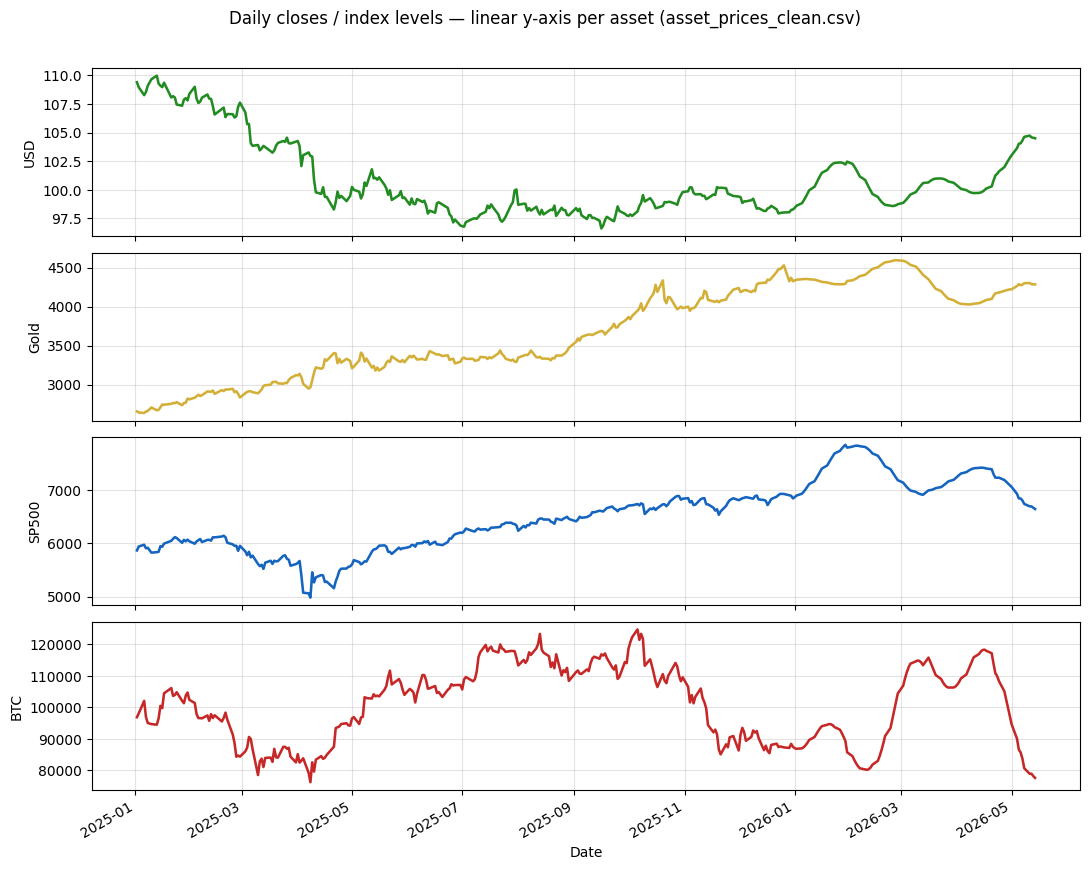

In [138]:
# =============================================================================
# Figure — four asset series (data overview)
# =============================================================================
# One subplot per asset so each keeps its native linear scale (CSV columns differ by instrument).
display(Markdown("### Daily asset levels (four panels, native units each)"))

# Daily levels in native units (not rebased).
_px_ov = asset_prices.rename(
    columns={"Date": "date", "GOLD": "Gold", "SP500": "SP500", "BTC": "BTC", "USD": "USD"}
).copy()
_px_ov["date"] = pd.to_datetime(_px_ov["date"])
_px_ov = _px_ov.sort_values("date")

fig_ov, axes_ov = plt.subplots(4, 1, figsize=(11, 10), sharex=True)
for ax, col in zip(axes_ov, ASSET_ORDER):
    ax.plot(_px_ov["date"], _px_ov[col], color=ASSET_COLORS[col], linewidth=1.85)
    ax.set_ylabel(col)
    ax.grid(alpha=0.35)

axes_ov[-1].set_xlabel("Date")
fig_ov.suptitle("Daily closes / index levels — linear y-axis per asset (asset_prices_clean.csv)")
fig_ov.tight_layout(rect=[0, 0, 1, 0.97])
fig_ov.autofmt_xdate()
display(fig_ov)
plt.close(fig_ov)


# Model / Methods

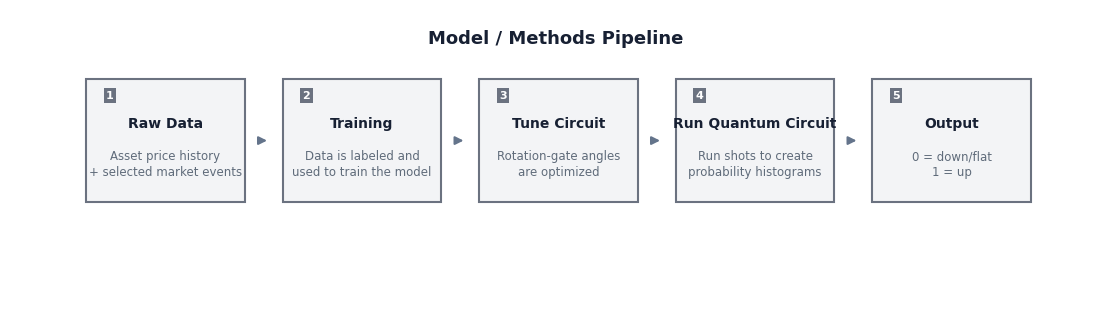

In [139]:
# Schematic pipeline

from matplotlib.patches import FancyArrowPatch, Rectangle

fig, ax = plt.subplots(figsize=(12.5, 4.2), constrained_layout=True)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
fig.patch.set_facecolor("white")

ink = "#172033"
muted = "#5f6b7a"
box_fill = "#f3f4f6"
box_edge = "#6b7280"
arrow = "#64748b"

# Boxes left-to-right: data → train → tune → simulate → readout.
# Boxes left-to-right: data → train → tune → simulate → readout.
# Boxes left-to-right: data → train → tune → simulate → readout.
steps = [
    ("Raw Data", "Asset price history\n+ selected market events"),
    ("Training", "Data is labeled and\nused to train the model"),
    ("Tune Circuit", "Rotation-gate angles\nare optimized"),
    ("Run Quantum\nCircuit", "Run shots to create\nprobability histograms"),
    ("Output", "0 = down/flat\n1 = up"),
]

n_steps = len(steps)
w, h, y = 0.168, 0.58, 0.22
xs = np.linspace(0.04, 1.0 - w - 0.04, n_steps)

for i, ((title, body), x) in enumerate(zip(steps, xs), start=1):
    ax.add_patch(Rectangle((x, y), w, h, fc=box_fill, ec=box_edge, lw=1.5))
    ax.text(x + 0.022, y + h - 0.07, f"{i}", ha="left", va="center", fontsize=10,
            fontweight="bold", color="white", bbox=dict(boxstyle="square,pad=0.22", fc=box_edge, ec=box_edge, lw=0))
    ax.text(x + w / 2, y + h * 0.68, title, ha="center", va="center", fontsize=12,
            fontweight="semibold", color=ink, linespacing=1.15)
    ax.text(x + w / 2, y + h * 0.32, body, ha="center", va="center", fontsize=11,
            color=muted, linespacing=1.3)

for x1, x2 in zip(xs[:-1], xs[1:]):
    ax.add_patch(FancyArrowPatch((x1 + w + 0.008, y + h / 2), (x2 - 0.008, y + h / 2),
                                 arrowstyle="-|>", mutation_scale=12, lw=1.5, color=arrow))

ax.text(0.5, 0.93, "Model / Methods Pipeline", ha="center", va="center",
        fontsize=16, fontweight="semibold", color=ink)

fig.savefig(FIG_DIR / "poster_model_methods_pipeline.png", dpi=300, bbox_inches="tight", facecolor="white")  # methods flowchart for poster
plt.show()


## Figure 1 — example circuit (untrained θ = 0)

The 34 trainable parameters θ are set to zero (CRY, RZZ, and readout gates add no rotation at θ=0). The five input RYs at the left still encode the first inputs.

### Input RY angles for this diagram (same order as gates on wires q0…q4)

,qubit,feature f_i,RY θ (rad)
0,q0,0.395823,1.243515
1,q1,0.000000,0.000000
2,q2,-0.489750,-0.769298
3,q3,0.000000,0.000000
4,q4,0.000000,0.000000


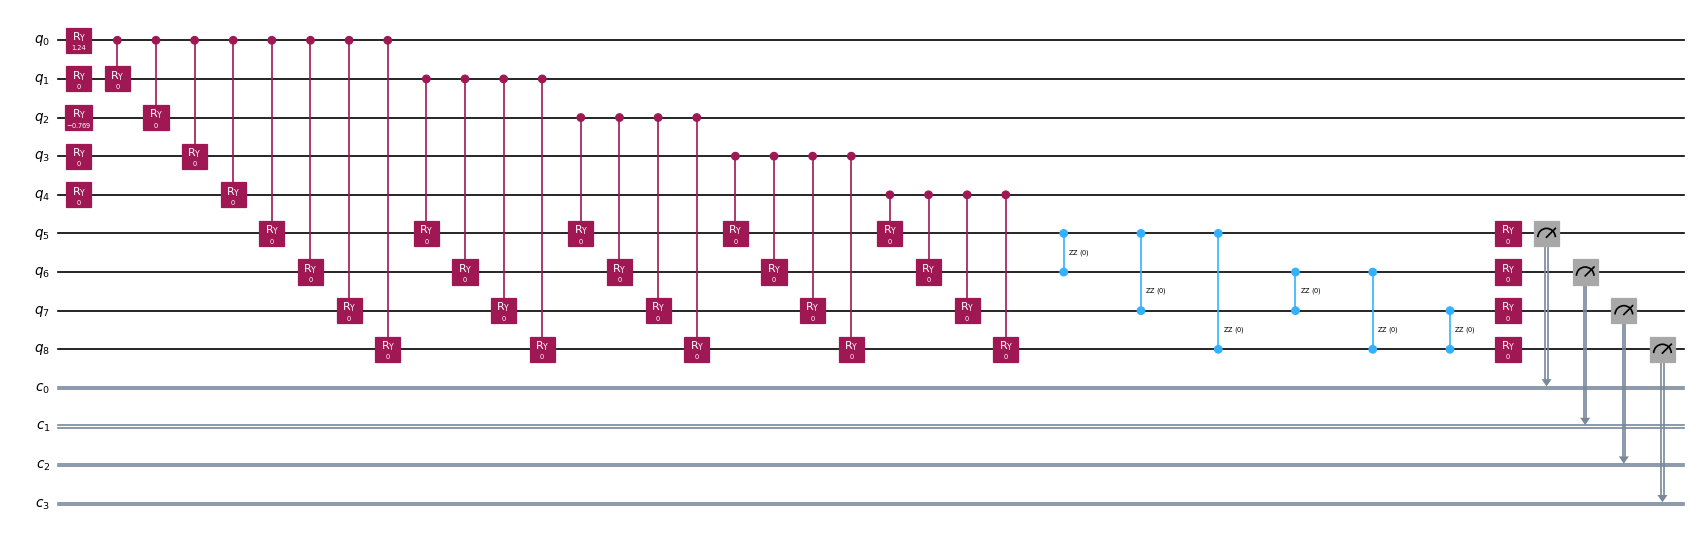

In [140]:
# =============================================================================
# Figure 1 — example circuit (untrained θ = 0)
# =============================================================================
# All trainable angles are zero; wiring shows structure. Input RYs use feature encoding from build_circuit.
display(Markdown("## Figure 1 — example circuit (untrained θ = 0)"))
display(Markdown(
    "The 34 trainable parameters θ are set to zero (CRY, RZZ, and readout gates add no rotation at θ=0). "
    "The five input RYs at the left still encode the first inputs."
))

# Use the first training row so RY labels match a real encoded headline.
# Use the first training row so RY labels match a real encoded headline.
example_features = training.iloc[0][FEATURE_COLS].to_numpy(dtype=float)
encoding_angles = np.array(
    [
        np.pi * example_features[0],
        (np.pi / 2.0) * example_features[1],
        (np.pi / 2.0) * example_features[2],
        (np.pi / 2.0) * example_features[3],
        (np.pi / 2.0) * example_features[4],
    ]
)
encoding_table = pd.DataFrame(
    {
        "qubit": [f"q{i}" for i in range(5)],
        "feature f_i": example_features,
        "RY θ (rad)": encoding_angles,
    }
)
display(Markdown("### Input RY angles for this diagram (same order as gates on wires q0…q4)"))
display(encoding_table)

# Zero vector: only input RYs rotate; CRY/RZZ/readout angles are 0.
# Zero vector: only input RYs rotate; CRY/RZZ/readout angles are 0.
theta_demo = np.zeros(count_parameters(num_layers=1), dtype=float)
qc_demo = build_circuit(example_features, theta_demo, num_layers=1, add_measurements=True)
# Label the five leftmost RY gates in the matplotlib diagram.
# Label the five leftmost RY gates in the matplotlib diagram.
for i in range(5):
    op = qc_demo.data[i].operation
    if op.name == "ry":
        theta_enc = float(op.params[0])
        try:
            op.label = f"θ={theta_enc:.4f}"
        except (AttributeError, TypeError):
            continue

# Save static circuit layout figure for the paper.
# Save static circuit layout figure for the paper.
fig_demo = draw_circuit_mpl(qc_demo)
fig_demo.savefig(FIG_DIR / "finetuned_circuit_demo.png", dpi=200, bbox_inches="tight")  # untrained-circuit layout figure
display(fig_demo)


### Trained circuit

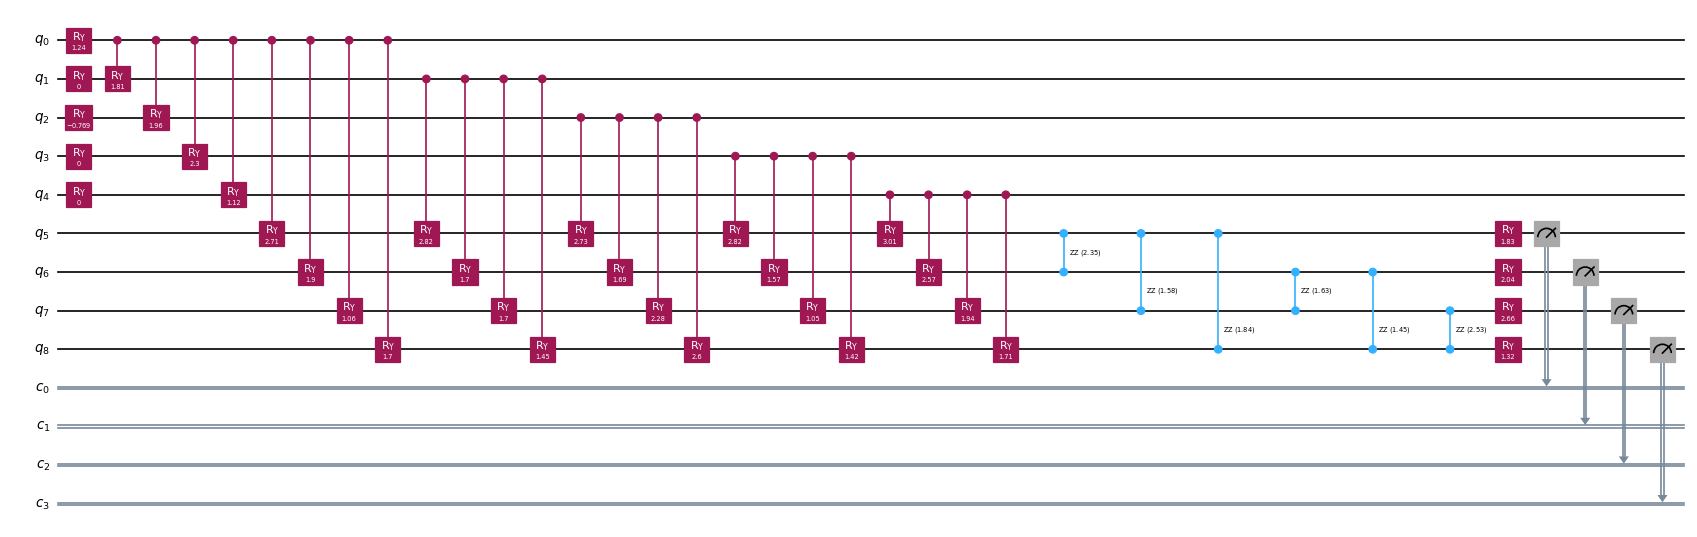

In [141]:
# =============================================================================
# Load trained parameters + helpers
# =============================================================================
# Prefer full COBYLA checkpoint; fall back to smoke JSON if missing.
# Prefer full COBYLA checkpoint; fall back to smoke JSON if missing.
params_path = MODELS_DIR / "updated_circuit_params.json"  # trained PQC angles + COBYLA metrics from train_quantum_model.py
smoke_path = MODELS_DIR / "updated_circuit_params_smoke.json"  # tiny fallback checkpoint for structure-only demos
selected_path = params_path if params_path.exists() else smoke_path
if not selected_path.exists():
    raise FileNotFoundError("No parameter JSON found in models/.")

payload = json.loads(selected_path.read_text())  # parse parameter_vector and training metadata
theta = np.array(payload["parameter_vector"], dtype=float)
num_layers = int(payload.get("num_layers", 1))


def predict_row_probabilities(row: pd.Series) -> dict:
    """Run predict_one for one CSV row; return marginal P(up) per asset."""
    feats = row[FEATURE_COLS].to_numpy(dtype=float)
    pred = predict_one(feats, theta, num_layers=num_layers)
    return {
        "P_USD_up": float(pred["marginals"]["USD"]),
        "P_Gold_up": float(pred["marginals"]["Gold"]),
        "P_SP500_up": float(pred["marginals"]["SP500"]),
        "P_BTC_up": float(pred["marginals"]["BTC"]),
    }


def display_trained_circuit_for_event(event_id: str, save_figure: bool = True):
    """Draw the trained circuit for one event_id and optionally save PNG."""
    row = training[training["event_id"] == event_id]
    if row.empty:
        raise ValueError(f"event_id not in training table: {event_id}")
    feats = row.iloc[0][FEATURE_COLS].to_numpy(dtype=float)
    qc_event = build_circuit(feats, theta, num_layers=num_layers, add_measurements=True)
    fig_event = draw_circuit_mpl(qc_event)
    if save_figure:
        fig_event.savefig(FIG_DIR / f"finetuned_trained_{event_id}.png", dpi=220, bbox_inches="tight")  # circuit diagram PNG
    display(Markdown(f"### Trained circuit"))
    display(fig_event)


# Example diagram for the first catalog row.
# Example diagram for the first catalog row.
first_id = str(training.iloc[0]["event_id"])
display_trained_circuit_for_event(first_id, save_figure=True)


## Evaluation on the training table

Rebuild Table C and summarize Tables D–E. Probabilities are Born marginals (predict_one), not shot histograms.


In [142]:
# =============================================================================
# Build prediction_correctness (training / val / test only)
# =============================================================================
# Born marginals + 0.5 threshold vs usd_up…btc_up; writes Table C CSV.
# Attach event names from the catalog for readable Table C.
# Attach event names from the catalog for readable Table C.
merged = training.merge(all_events_lookup, on="event_id", how="left", suffixes=("", "_all"))

# Born marginals P(up) per asset for every training/val/test row.
# Born marginals P(up) per asset for every training/val/test row.
prob_records = [predict_row_probabilities(row) for _, row in merged.iterrows()]
pred_df = pd.concat([merged.reset_index(drop=True), pd.DataFrame(prob_records)], axis=1)

# Threshold 0.5: compare predicted up/down to stored labels.
# Threshold 0.5: compare predicted up/down to stored labels.
for asset in ASSET_ORDER:
    p_col = f"P_{asset}_up"
    pred_col = f"{asset}_pred"
    actual_col = f"{asset}_actual"
    correct_col = f"{asset}_correct"
    label_col = LABEL_TO_COL[asset]
    pred_df[pred_col] = (pred_df[p_col] >= 0.50).astype(int)
    pred_df[actual_col] = pred_df[label_col].astype(int)
    pred_df[correct_col] = (pred_df[pred_col] == pred_df[actual_col]).astype(int)

# Row-level score: how many of four assets were guessed correctly.
# Row-level score: how many of four assets were guessed correctly.
pred_df["num_assets_correct"] = pred_df[[f"{a}_correct" for a in ASSET_ORDER]].sum(axis=1)
pred_df["mean_probability_confidence"] = pred_df[[f"P_{a}_up" for a in ASSET_ORDER]].sub(0.5).abs().mean(axis=1)

pred_out = pred_df.rename(columns={"event_date": "date", "split": "train_val_test_split"})

columns_for_export = [
    "event_id",
    "date",
    "prediction_date",
    "event_name",
    "primary_category",
    "P_USD_up", "USD_pred", "USD_actual", "USD_correct",
    "P_Gold_up", "Gold_pred", "Gold_actual", "Gold_correct",
    "P_SP500_up", "SP500_pred", "SP500_actual", "SP500_correct",
    "P_BTC_up", "BTC_pred", "BTC_actual", "BTC_correct",
    "num_assets_correct",
    "mean_probability_confidence",
    "train_val_test_split",
]

prediction_correctness = pred_out[columns_for_export].copy()
# Export full per-event table used by Tables D/E and zoom plots.
# Export full per-event table used by Tables D/E and zoom plots.
prediction_correctness.to_csv(DATA_DIR / "model_prediction_correctness.csv", index=False)  # per-event Born marginals + correctness

display(Markdown("### Table C — first rows (full CSV on disk)"))
display(prediction_correctness.head(8))
print("Saved:", DATA_DIR / "model_prediction_correctness.csv")


### Table C — first rows (full CSV on disk)

,event_id,date,prediction_date,event_name,primary_category,P_USD_up,USD_pred,USD_actual,USD_correct,P_Gold_up,...,SP500_pred,SP500_actual,SP500_correct,P_BTC_up,BTC_pred,BTC_actual,BTC_correct,num_assets_correct,mean_probability_confidence,train_val_test_split
0,EVT_0051,2025-05-14,2025-05-21,Disruption signal: severe weather and transpor...,q2_disaster_disruption,0.530544,1,0,0,0.655026,...,1,0,0,0.464304,0,1,0,1,0.105813,train
1,EVT_0101,2025-05-14,2025-05-21,Consensus 2025 opens with institutional digita...,q3_technology_adoption,0.501013,1,0,0,0.668600,...,1,0,0,0.447056,0,1,0,1,0.124383,train
2,EVT_0151,2025-05-15,2025-05-22,Digital-asset market-structure bill / hearing ...,q4_regulation_policy,0.508178,1,0,0,0.638395,...,1,0,0,0.466212,0,1,0,1,0.108862,train
3,EVT_0102,2025-05-19,2025-05-27,Microsoft Build 2025 highlights enterprise AI ...,q3_technology_adoption,0.441746,0,0,1,0.646799,...,1,0,0,0.480561,0,1,0,2,0.103484,train
4,EVT_0103,2025-05-20,2025-05-28,Google I/O 2025 highlights AI product adoption,q3_technology_adoption,0.423106,0,0,1,0.637939,...,1,0,0,0.490948,0,1,0,2,0.097381,train
5,EVT_0052,2025-05-22,2025-05-30,Disruption signal: infrastructure and accident...,q2_disaster_disruption,0.545161,1,0,0,0.668081,...,1,1,1,0.447445,0,0,1,2,0.128900,train
6,EVT_0152,2025-05-22,2025-05-30,SEC / crypto enforcement or guidance headline ...,q4_regulation_policy,0.377220,0,0,1,0.612003,...,1,1,1,0.518926,1,0,0,2,0.079814,train
7,EVT_0104,2025-05-27,2025-06-03,Bitcoin 2025 conference begins in Las Vegas,q3_technology_adoption,0.447986,0,0,1,0.645968,...,1,1,1,0.476839,0,0,1,4,0.106041,train


Saved: /Users/justinoliver/SJSU/PHYS 250 - Quantum Programing/final project/data/model_prediction_correctness.csv


In [143]:
# =============================================================================
# Table D / E — by split and by asset
# =============================================================================
# Aggregate row accuracy by split and per-asset hit rate on the full training table.
# Mean accuracy and confidence grouped by train / val / test split.
split_summary = (
    prediction_correctness.assign(row_accuracy=prediction_correctness["num_assets_correct"] / 4.0)
    .groupby("train_val_test_split", as_index=False)
    .agg(
        rows=("event_id", "count"),
        mean_assets_correct=("num_assets_correct", "mean"),
        mean_row_accuracy=("row_accuracy", "mean"),
        mean_confidence=("mean_probability_confidence", "mean"),
    )
)

# Per-asset hit rate across all labeled rows.
asset_summary = pd.DataFrame(
    {
        "asset": ASSET_ORDER,
        "accuracy": [prediction_correctness[f"{a}_correct"].mean() for a in ASSET_ORDER],
        "mean_P_up": [prediction_correctness[f"P_{a}_up"].mean() for a in ASSET_ORDER],
    }
)

display(Markdown("### Table D — performance by split"))
display(split_summary.style.format({"mean_assets_correct": "{:.3f}", "mean_row_accuracy": "{:.3f}", "mean_confidence": "{:.3f}"}))

display(Markdown("### Table E — performance by asset"))
display(asset_summary.style.format({"accuracy": "{:.3f}", "mean_P_up": "{:.3f}"}))


### Table D — performance by split

,train_val_test_split,rows,mean_assets_correct,mean_row_accuracy,mean_confidence
0,test,30,1.867,0.467,0.092
1,train,140,2.314,0.579,0.090
2,val,30,2.233,0.558,0.098


### Table E — performance by asset

,asset,accuracy,mean_P_up
0,USD,0.545,0.461
1,Gold,0.575,0.629
2,SP500,0.660,0.666
3,BTC,0.455,0.486


## Figures — normalized prices

Figure 3 uses the Okabe–Ito palette in that cell (USD blue, Gold orange, SP500 green, BTC pink-purple). Event markers were removed so only normalized asset curves remain.


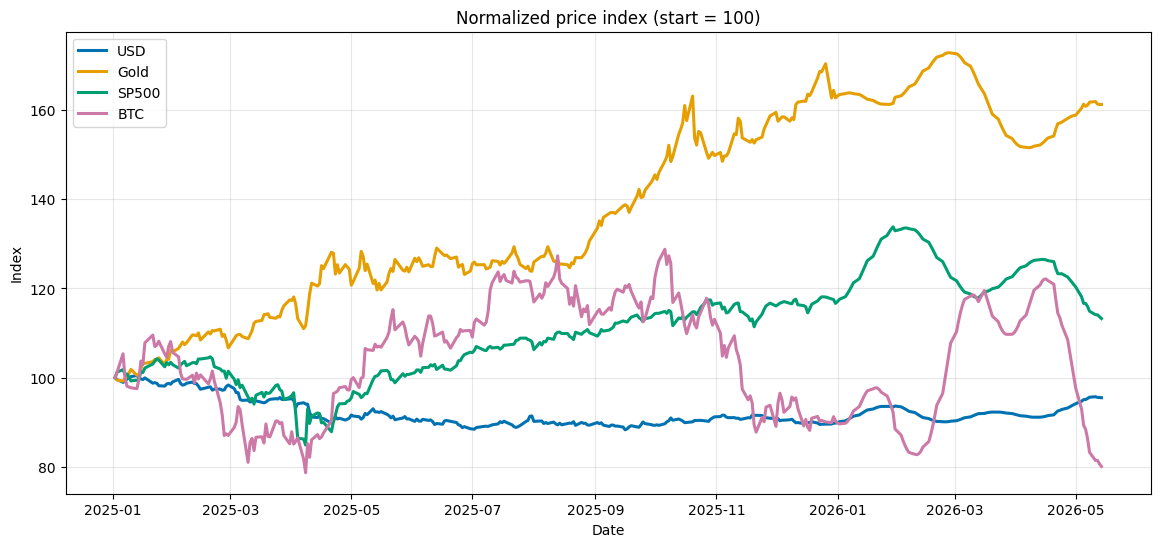

In [144]:
# =============================================================================
# Figure 3 — long-run normalized index
# =============================================================================
# Long-run rebased price index (start-of-sample = 100).
# Long-run daily levels used for the normalized timeline figure.
prices = asset_prices.rename(
    columns={"Date": "date", "GOLD": "Gold", "SP500": "SP500", "BTC": "BTC", "USD": "USD"}
).copy()
prices["date"] = pd.to_datetime(prices["date"])
prices = prices.sort_values("date")

plot_assets = ["USD", "Gold", "SP500", "BTC"]
# Rebase each series to 100 at its first non-null observation.
for col in plot_assets:
    first = prices[col].dropna().iloc[0]
    prices[f"norm_{col}"] = 100.0 * prices[col] / first

asset_line_colors = {"USD": "#0072B2", "Gold": "#E69F00", "SP500": "#009E73", "BTC": "#CC79A7"}

fig, ax = plt.subplots(figsize=(14, 6))
for col in plot_assets:
    ax.plot(prices["date"], prices[f"norm_{col}"], label=col, linewidth=2.2, color=asset_line_colors[col])

ax.set_title("Normalized price index (start = 100)", fontsize=15)
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Index", fontsize=14)
ax.tick_params(labelsize=13)
ax.legend(loc="upper left", fontsize=13)
ax.grid(alpha=0.3)
# Paper Figure: training-window price scope.
fig.savefig(FIG_DIR / "finetuned_normalized_timeline.png", dpi=220, bbox_inches="tight")  # long-run rebased index PNG
plt.show()



### Localized window: EVT_0190

### Trained circuit

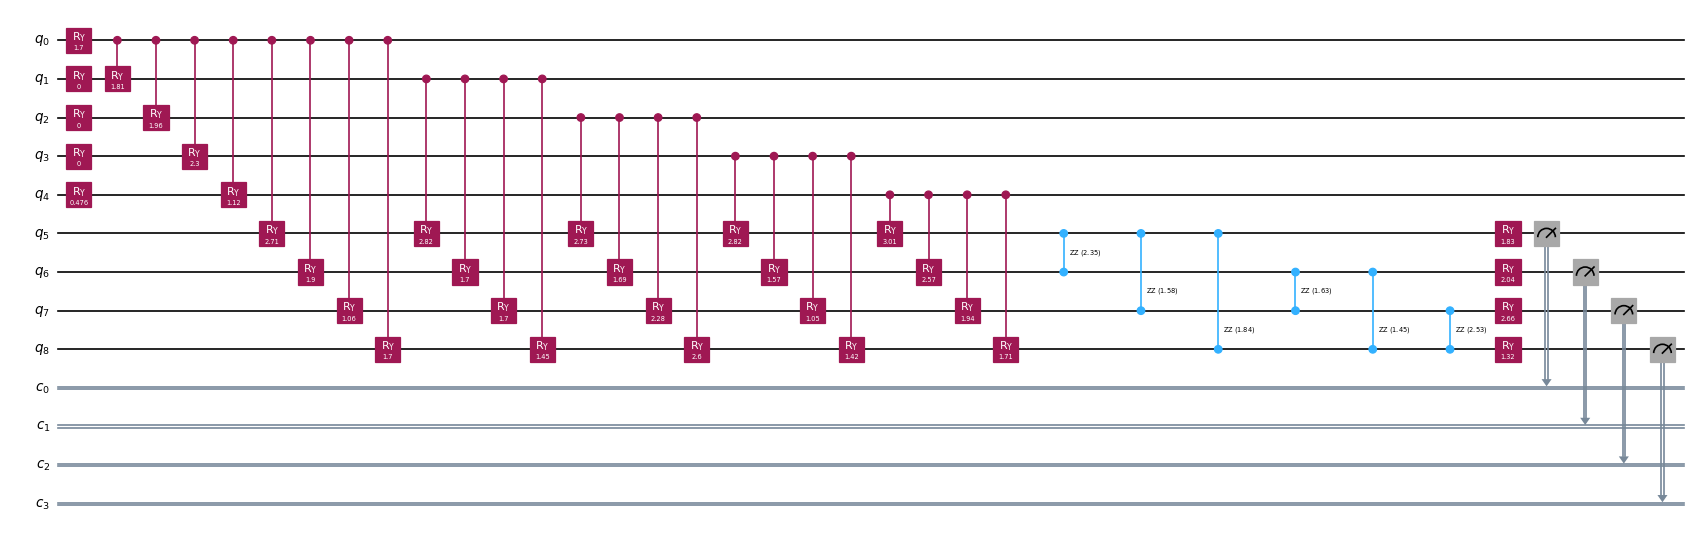

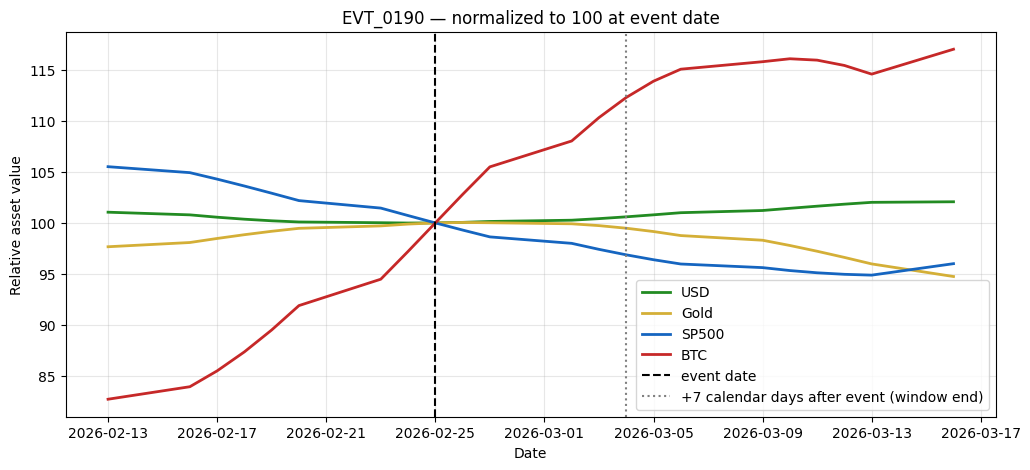

,asset,P_up,pred_up,actual_up,correct
0,USD,0.493622,0,1,0
1,Gold,0.629067,1,0,0
2,SP500,0.732314,1,0,0
3,BTC,0.475381,0,1,0


In [145]:
# =============================================================================
# Figure 4 — zoom on first test-row event
# =============================================================================
# Local window around one test event; 100 at event date for all four assets.
prices_zoom = prices.copy()


def _nearest_price_index(date_series: pd.Series, target_date: pd.Timestamp) -> int:
    deltas = (date_series - target_date).abs()
    return int(deltas.idxmin())


def plot_one_event_zoom(event_id: str, window_days: int = 12):
    """Plot ±window_days around one event; rebase all assets to 100 on event day."""
    row = prediction_correctness[prediction_correctness["event_id"] == event_id].iloc[0]
    event_date = pd.to_datetime(row["date"])
    pred_date = pd.to_datetime(row["prediction_date"])
    start = event_date - pd.Timedelta(days=window_days)
    end = pred_date + pd.Timedelta(days=window_days)
    # Slice calendar window and normalize each asset to 100 at the event.
    # Slice calendar window and normalize each asset to 100 at the event.
    window = prices_zoom[(prices_zoom["date"] >= start) & (prices_zoom["date"] <= end)].copy()
    idx_base = _nearest_price_index(window["date"], event_date)
    base_row = window.loc[idx_base]
    for col in ASSET_ORDER:
        window[f"zoom_{col}"] = 100.0 * window[col] / base_row[col]

    fig, ax = plt.subplots(figsize=(12, 5))
    for col in ASSET_ORDER:
        ax.plot(
            window["date"],
            window[f"zoom_{col}"],
            label=col,
            linewidth=2,
            color=ASSET_COLORS[col],
        )
    ax.axvline(event_date, color="black", linestyle="--", linewidth=1.5, label="event date")
    nh = int((pred_date.normalize() - event_date.normalize()).days)
    ax.axvline(
        pred_date,
        color="gray",
        linestyle=":",
        linewidth=1.5,
        label=f"+{nh} calendar days after event (window end)",
    )
    ax.set_title(f"{event_id} — normalized to 100 at event date")
    ax.set_xlabel("Date")
    ax.set_ylabel("Relative asset value")
    ax.grid(alpha=0.3)
    ax.legend(loc="best")
    fig.savefig(FIG_DIR / f"finetuned_zoom_{event_id}.png", dpi=220, bbox_inches="tight")  # localized price window PNG
    plt.show()

    details = pd.DataFrame(
        {
            "asset": ASSET_ORDER,
            "P_up": [row[f"P_{a}_up"] for a in ASSET_ORDER],
            "pred_up": [row[f"{a}_pred"] for a in ASSET_ORDER],
            "actual_up": [row[f"{a}_actual"] for a in ASSET_ORDER],
            "correct": [row[f"{a}_correct"] for a in ASSET_ORDER],
        }
    )
    display(details)


# Pick first test-split event for the zoom example (fallback: any row).
# Pick first test-split event for the zoom example (fallback: any row).
test_rows = prediction_correctness[prediction_correctness["train_val_test_split"] == "test"]
example_event = str(test_rows.iloc[0]["event_id"]) if len(test_rows) else str(prediction_correctness.iloc[0]["event_id"])

display(Markdown(f"### Localized window: {example_event}"))
display_trained_circuit_for_event(example_event, save_figure=True)
plot_one_event_zoom(example_event, window_days=12)



## Holdout case studies (not in training)

For each of the three rows in holdout_events.csv we:

1. Rebuild the same five circuit inputs the training pipeline uses (including same-day attention and trend dampening).
2. Run AerSimulator once per event with shots=1000 (seed derived from event_id for reproducibility). P_up for each asset is the marginal fraction of shots where that asset’s readout bit was 1 (“up”), computed from the raw get_counts() histogram for that single execution.
3. Compare to the actual multi-day label (usd_up, …) from the compounded return window.

Readout bit order (verified for this wiring): in the 4-character count string, index 0 = BTC, 1 = SP500, 2 = Gold, 3 = USD.

The tables use P_up from those shot readouts (not Born/statevector marginals), threshold 0.5 for pred_up, and correct vs the realized multi-day sign.


In [146]:
# =============================================================================
# CELL: Holdout case studies — Aer shot marginals (events never in training)
# =============================================================================

# Label holdouts with the same 5-day return rule as training.
# Label holdouts with the same 5-day return rule as training.
from build_training_events import (
    RETURNS_PATH,
    build_labeled_event_frame,
    _load_events,
    _load_returns,
    FEATURE_COLUMNS,
)

SHOTS = 1000

hold_raw = _load_events(DATA_DIR / "holdout_events.csv")  # Tim Cook, Canvas, Spirit (never in training)
returns_df = _load_returns(RETURNS_PATH)  # asset_returns_clean.csv — rebuild 5-day label windows
# Attach usd_up..btc_up and prediction_date for each holdout headline.
# Attach usd_up..btc_up and prediction_date for each holdout headline.
labeled_hold, _hstats = build_labeled_event_frame(
    hold_raw,
    returns_df,
    label_horizon=LABEL_HORIZON,
    fuse_market=False,
    temporal_cutoff=None,
    enforce_temporal_cutoff=False,
)

name_lookup = hold_raw.set_index("event_id")["event_name"].to_dict()

# One AerSimulator run per holdout; seed is deterministic from event_id.
# One AerSimulator run per holdout; seed is deterministic from event_id.
for _, row in labeled_hold.iterrows():
    eid = row["event_id"]
    seed = holdout_event_shot_seed(str(eid), base=1000)
    feats = row[FEATURE_COLUMNS].to_numpy(dtype=float)
    # Shot fractions for P(asset reads 1), not Born statevector marginals.
    # Shot fractions for P(asset reads 1), not Born statevector marginals.
    probs = marginal_probs_from_aer_shots(feats, theta, num_layers, shots=SHOTS, seed=seed)

    enc = pd.DataFrame({
        "feature": FEATURE_COLUMNS,
        "circuit_input_value": feats,
        "raw_from_csv": [float(row[f"raw_{c}"]) for c in FEATURE_COLUMNS],
    })
    display(Markdown(f"### {name_lookup.get(eid, eid)} ({eid})"))
    display(Markdown(
        f"- Label window: {row['label_start_date']} → {row['label_end_date']} "
        f"({int(row['label_horizon_trading_days'])} trading rows)\n"
        f"- q0 RY angle: π × q0 = {np.pi * feats[0]:.4f} rad\n"
        f"- P_up: marginal fraction of `1` in {SHOTS} Aer shots (raw readouts)"
    ))
    display(enc.style.format({"circuit_input_value": "{:.4f}", "raw_from_csv": "{:.4f}"}).hide(axis="index"))

    tbl = pd.DataFrame([
        {
            "asset": a,
            "P_up": probs[a],
            "pred_up": int(probs[a] >= 0.5),
            "actual_up": int(row[LABEL_TO_COL[a]]),
            "correct": int(int(probs[a] >= 0.5) == int(row[LABEL_TO_COL[a]])),
        }
        for a in ASSET_ORDER
    ])
    display(tbl.style.format({"P_up": "{:.6f}"}).hide(axis="index"))

# Markdown report (same shot marginals as tables above)
# Write markdown report mirroring the tables above.
# Write markdown report mirroring the tables above.
_ = run_holdout_eval(
    params_path=selected_path,  # updated_circuit_params.json (trained theta)
    holdout_path=DATA_DIR / "holdout_events.csv",  # same three events as holdouts table
    returns_path=DATA_DIR / "asset_returns_clean.csv",  # daily returns through holdout era
    output_path=DATA_DIR / "holdout_eval_report_notebook.md",  # markdown summary of holdout shot marginals
    label_horizon=LABEL_HORIZON,
    fuse_market=False,
    use_shot_marginals=True,
    shots=SHOTS,
    shot_seed_base=1000,
)
print("Wrote data/holdout_eval_report_notebook.md")


### Tim Cook stepping down as Apple CEO (EVT_9001)

- Label window: 2026-04-21 → 2026-04-27 (5 trading rows)
- q0 RY angle: π × q0 = 2.2619 rad
- P_up: marginal fraction of `1` in 1000 Aer shots (raw readouts)

feature,circuit_input_value,raw_from_csv
q0_overall_intensity,0.7200,0.7200
q1_geo_macro_score,0.0000,0.0000
q2_disaster_disruption_score,0.0000,0.0000
q3_technology_adoption_score,-0.4500,-0.4500
q4_regulation_policy_score,0.0000,0.0000


asset,P_up,pred_up,actual_up,correct
USD,0.464000,0,1,0
Gold,0.558000,1,1,1
SP500,0.609000,1,0,0
BTC,0.515000,1,0,0


### Spirit Airlines orderly wind-down announcement (EVT_9003)

...

### Canvas unauthorized-actor threat (EVT_9002)

- Label window: 2026-05-08 → 2026-05-14 (5 trading rows)
- q0 RY angle: π × q0 = 1.5869 rad
- P_up: marginal fraction of `1` in 1000 Aer shots (raw readouts)

feature,circuit_input_value,raw_from_csv
q0_overall_intensity,0.5051,0.7900
q1_geo_macro_score,0.0000,0.0000
q2_disaster_disruption_score,-0.3964,-0.6200
q3_technology_adoption_score,-0.1407,-0.2200
q4_regulation_policy_score,0.0000,0.0000


asset,P_up,pred_up,actual_up,correct
USD,0.508000,1,1,1
Gold,0.614000,1,1,1
SP500,0.629000,1,0,0
BTC,0.486000,0,0,1


Wrote data/holdout_eval_report_notebook.md


## Poster figures (six PNGs)

The next cell builds six print-quality figures (300 dpi) under figures/poster/, one holdout at a time in event_id order:

1. Five Bloch spheres in one horizontal matplotlib figure (1x5 subplot row) — labeled by human-readable headline and by role for each wire (example: q0 — Intensity qubit), not by internal EVT codes. Encoding matches quantum_market_model.build_circuit (intensity vs thematic pi scaling) before CRY entangling gates.
2. Prices — relative asset value (100 at event date) for each holdout; title Event name — YYYY-MM-DD — Normalized at event date; gray dotted line is +N trading days after the event (label window end).
3. Readouts — for each holdout: one Qiskit AerSimulator run (shots=1000); y-axis = shot counts (zoomed); x-axis caption is two lines: first line Joint readout (q5,q6,q7,q8) (USD,GOLD,SP500,BTC), second line Predicted (modal 4-bit string from shots), Actual (realized label), and % Accuracy (mean bit agreement between those two strings).

Re-run the cell after changing parameters or holdout data.


### Input qubits for Tim Cook stepping down as Apple CEO

Paper-friendly Bloch spheres (left to right: q0 through q4). The PQC initializes each headline wire separately from the computational ground state with one RY in build_circuit; each subplot title names the semantic role wired to q0 intensity vs q1 thematic channels. States lie in the xz plane of each sphere (effective azimuth phi = 0) because RY uses real rotations only; intensity wire q0 uses theta = pi times the intensity score while thematic wires use theta = (pi/2) times their scores (see quantum_market_model.build_circuit), before CRY layers couple news to USD, Gold, SP500, and BTC.

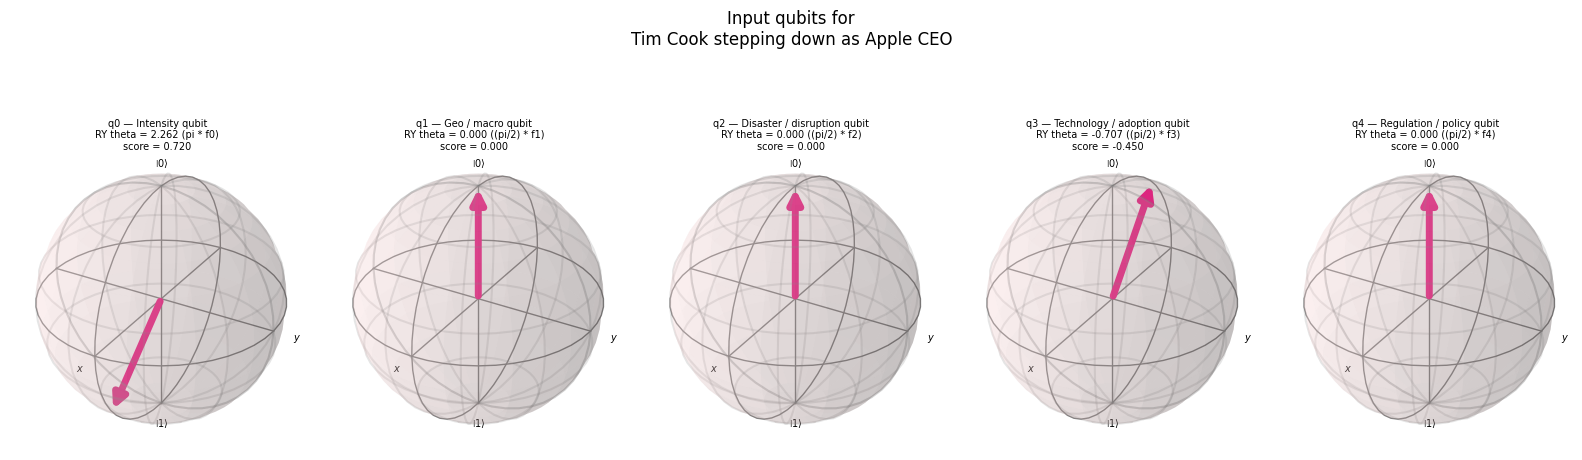

Price figure → figures/poster/poster_01_EVT_9001_prices.png

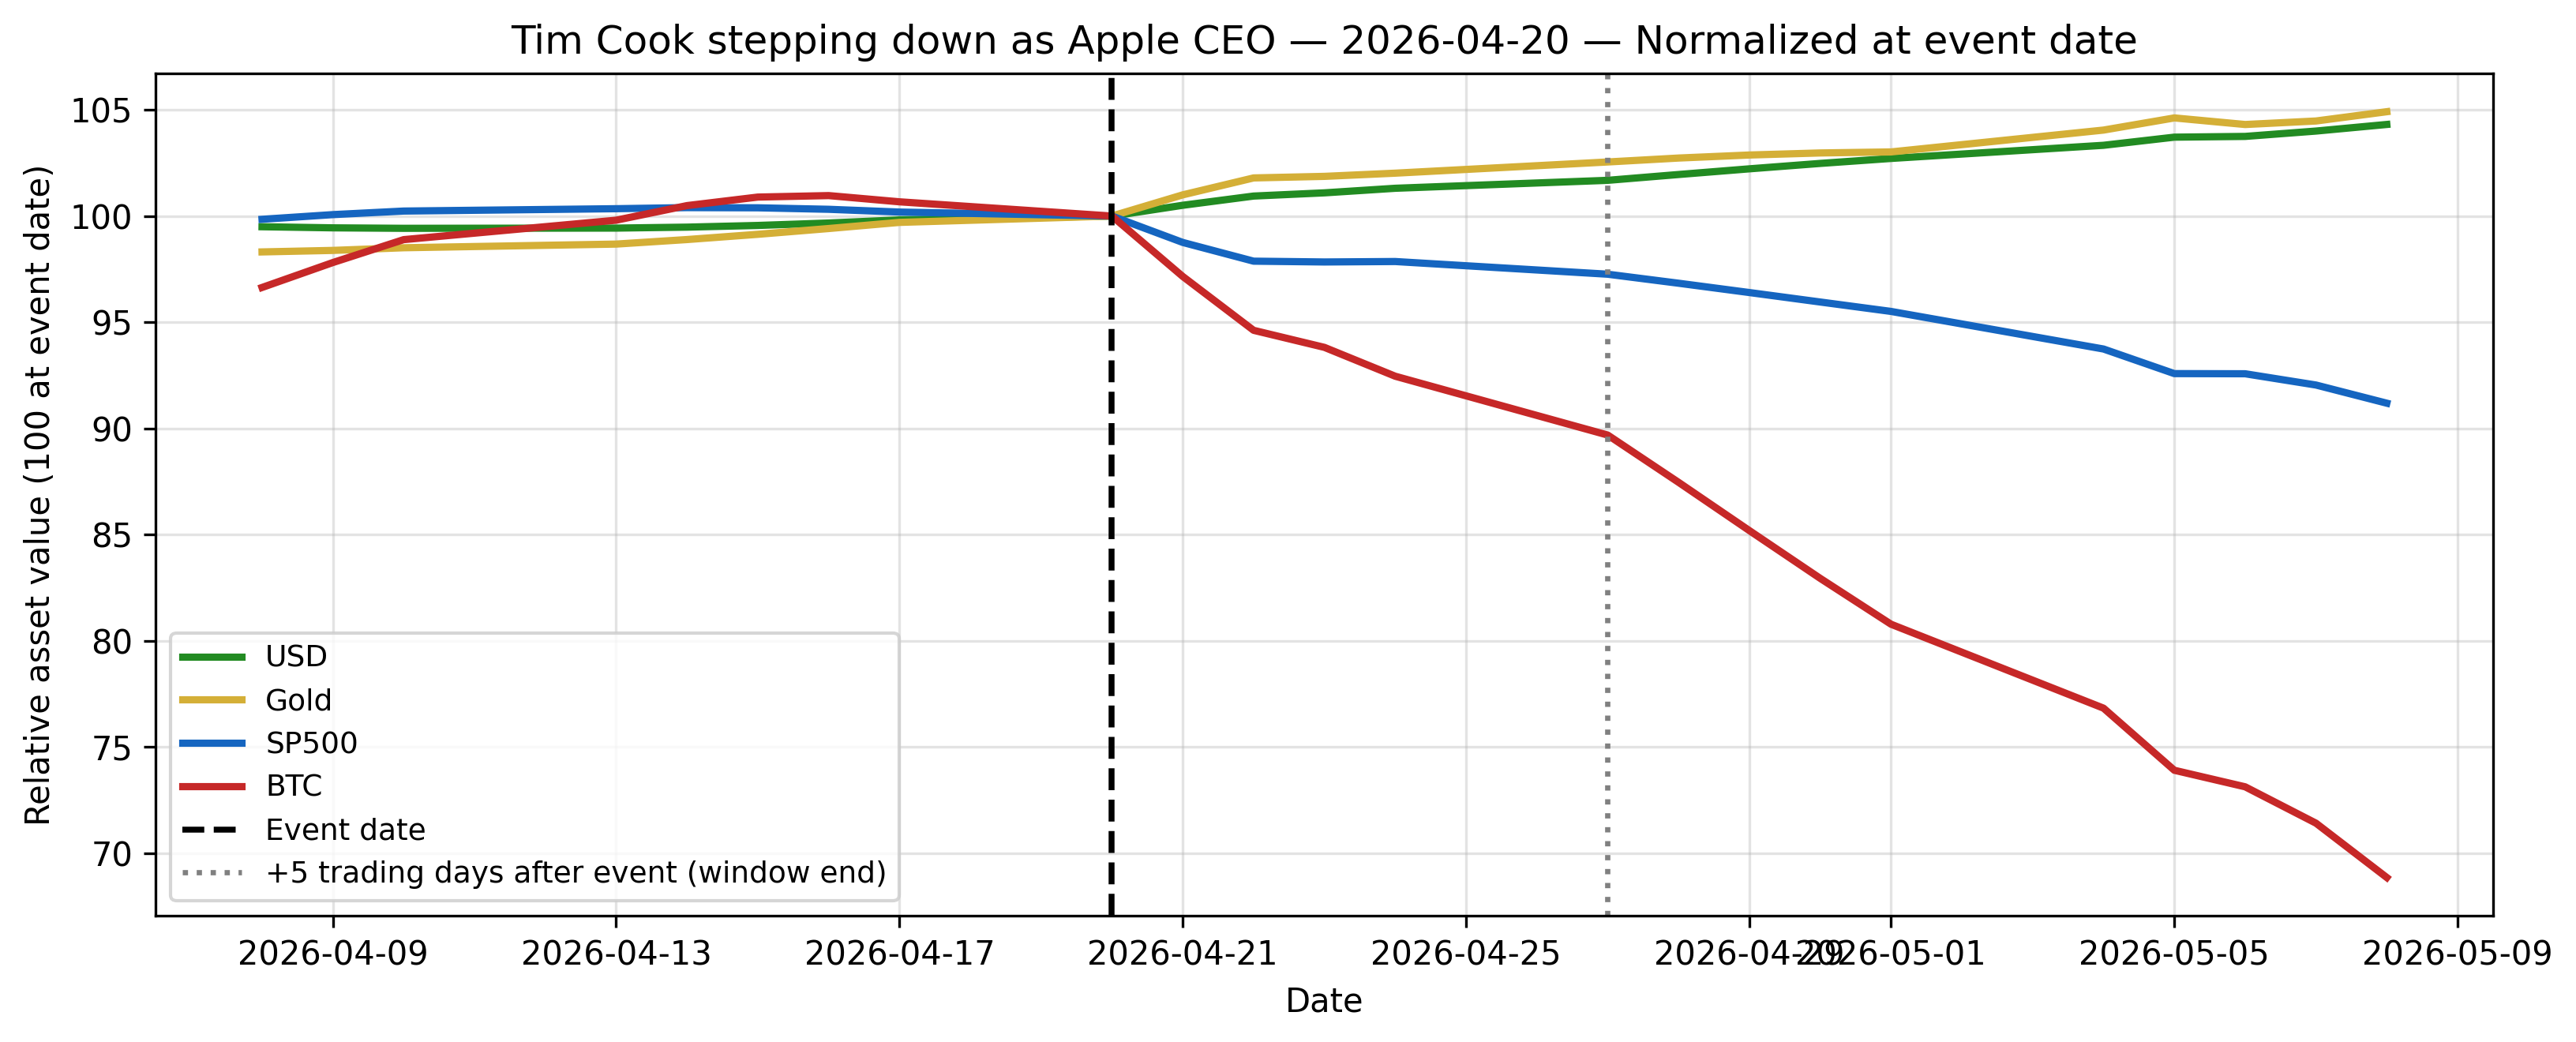

Measured shots (Qiskit Aer) → figures/poster/poster_04_EVT_9001_readout_shots.png

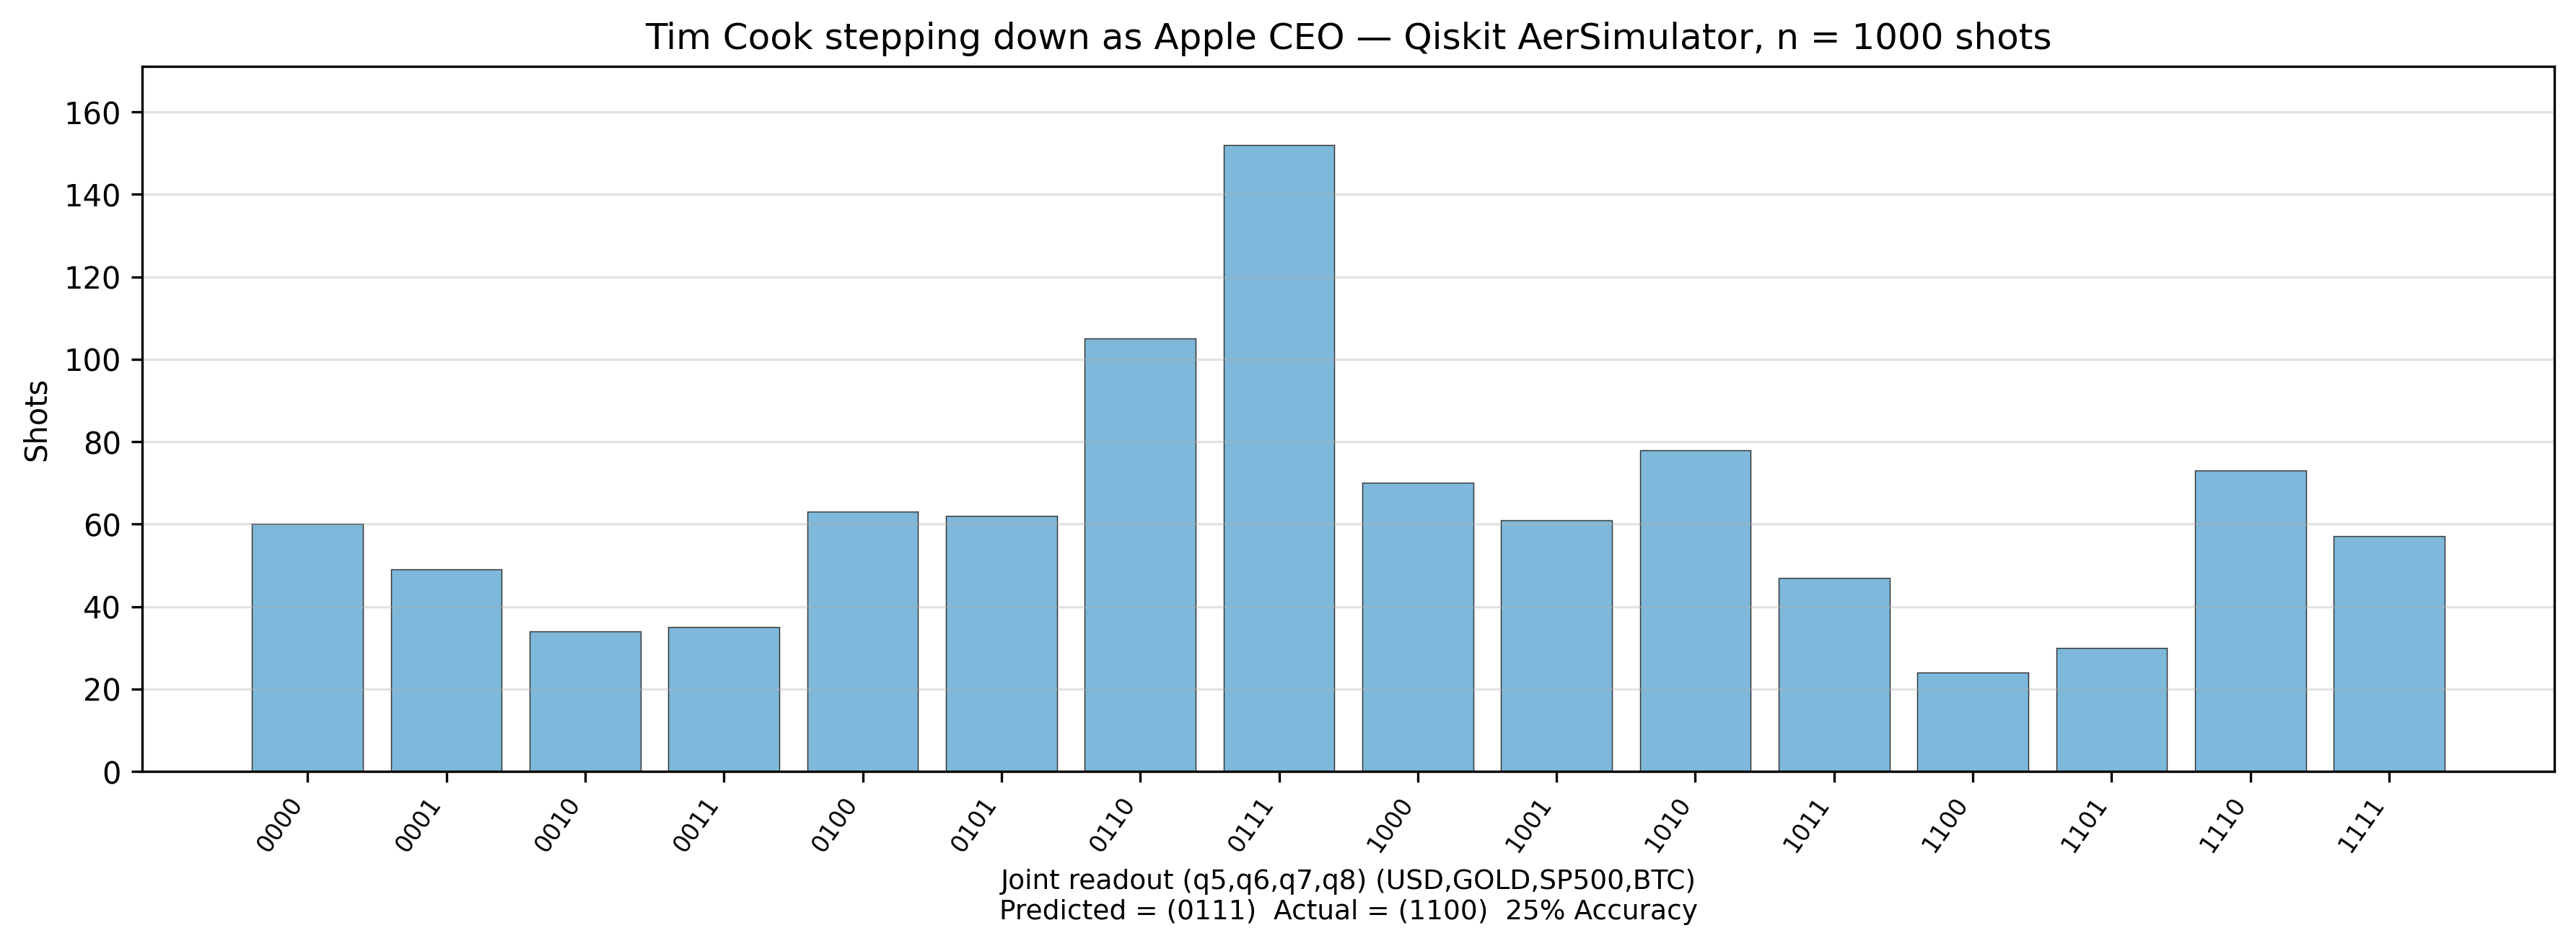

### Input qubits for Canvas unauthorized-actor threat

Paper-friendly Bloch spheres (left to right: q0 through q4). The PQC initializes each headline wire separately from the computational ground state with one RY in build_circuit; each subplot title names the semantic role wired to q0 intensity vs q1 thematic channels. States lie in the xz plane of each sphere (effective azimuth phi = 0) because RY uses real rotations only; intensity wire q0 uses theta = pi times the intensity score while thematic wires use theta = (pi/2) times their scores (see quantum_market_model.build_circuit), before CRY layers couple news to USD, Gold, SP500, and BTC.

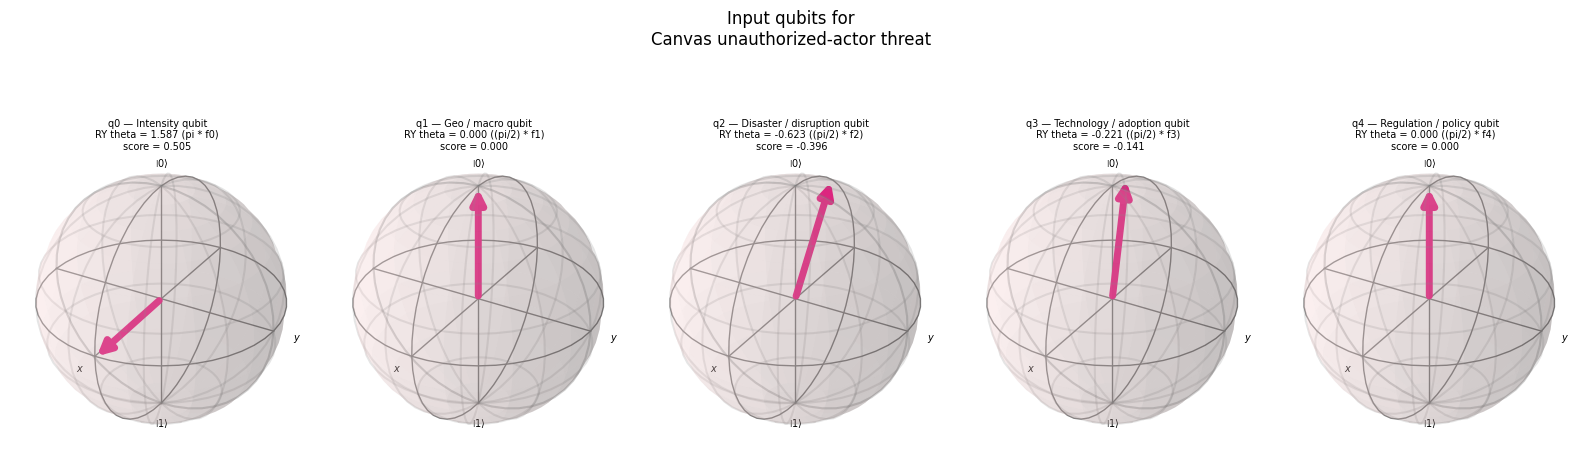

Price figure → figures/poster/poster_02_EVT_9002_prices.png

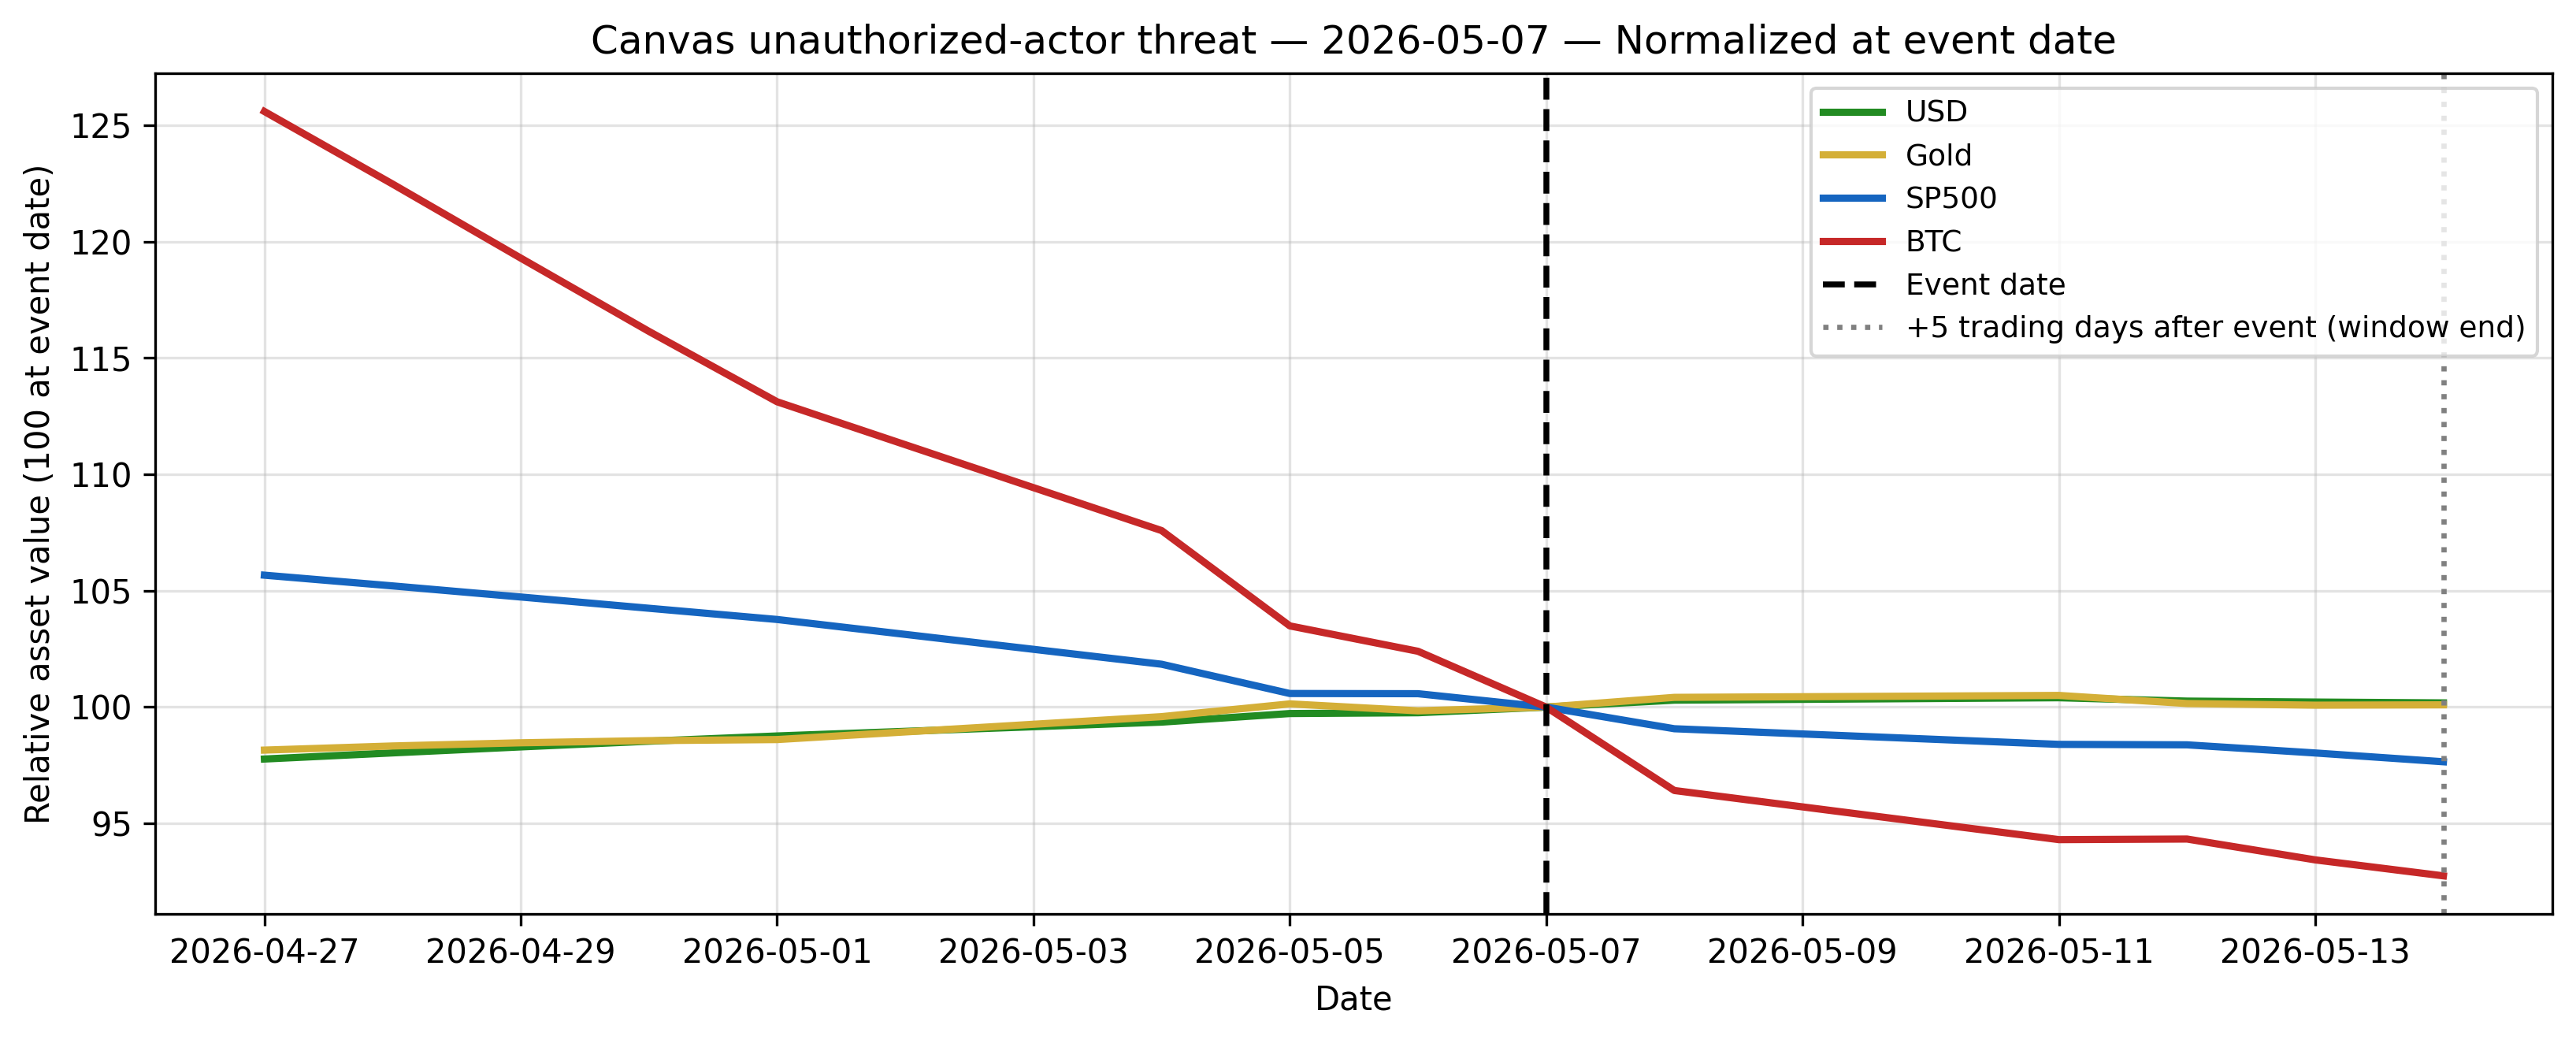

Measured shots (Qiskit Aer) → figures/poster/poster_05_EVT_9002_readout_shots.png

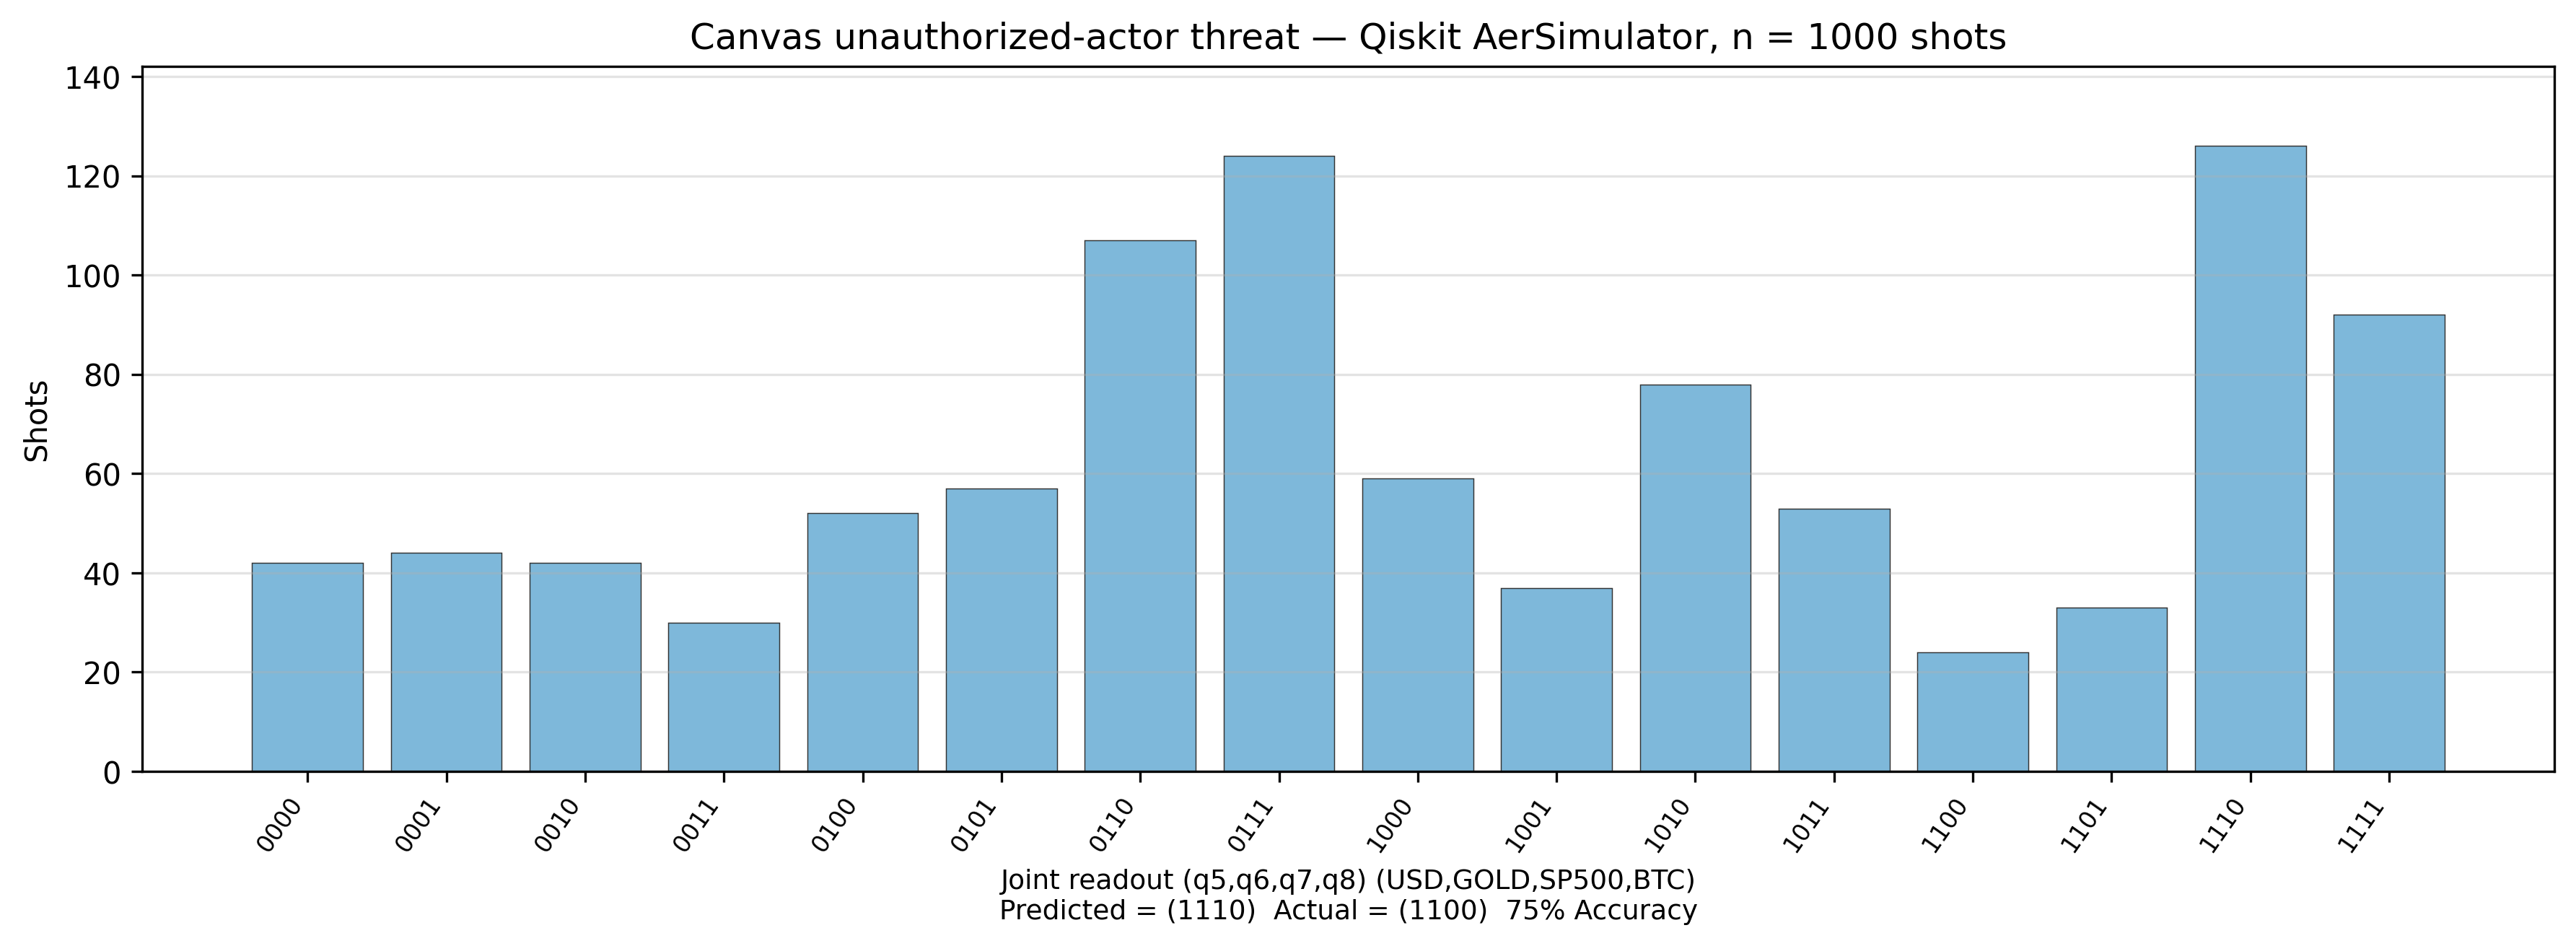

### Input qubits for Spirit Airlines orderly wind-down announcement

Paper-friendly Bloch spheres (left to right: q0 through q4). The PQC initializes each headline wire separately from the computational ground state with one RY in build_circuit; each subplot title names the semantic role wired to q0 intensity vs q1 thematic channels. States lie in the xz plane of each sphere (effective azimuth phi = 0) because RY uses real rotations only; intensity wire q0 uses theta = pi times the intensity score while thematic wires use theta = (pi/2) times their scores (see quantum_market_model.build_circuit), before CRY layers couple news to USD, Gold, SP500, and BTC.

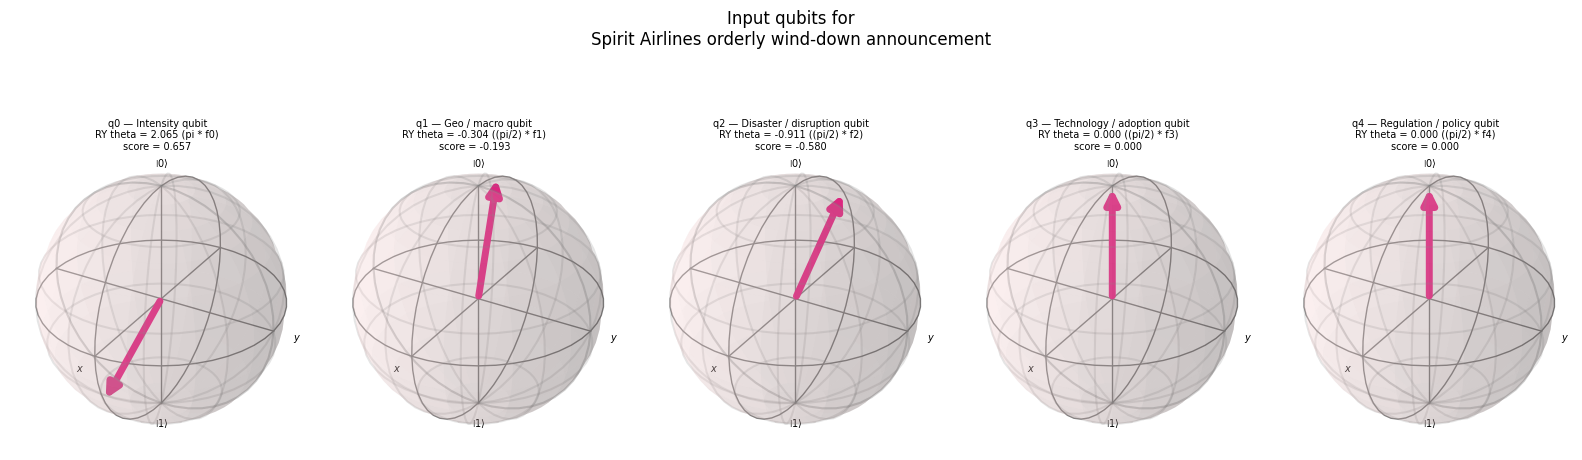

Price figure → figures/poster/poster_03_EVT_9003_prices.png

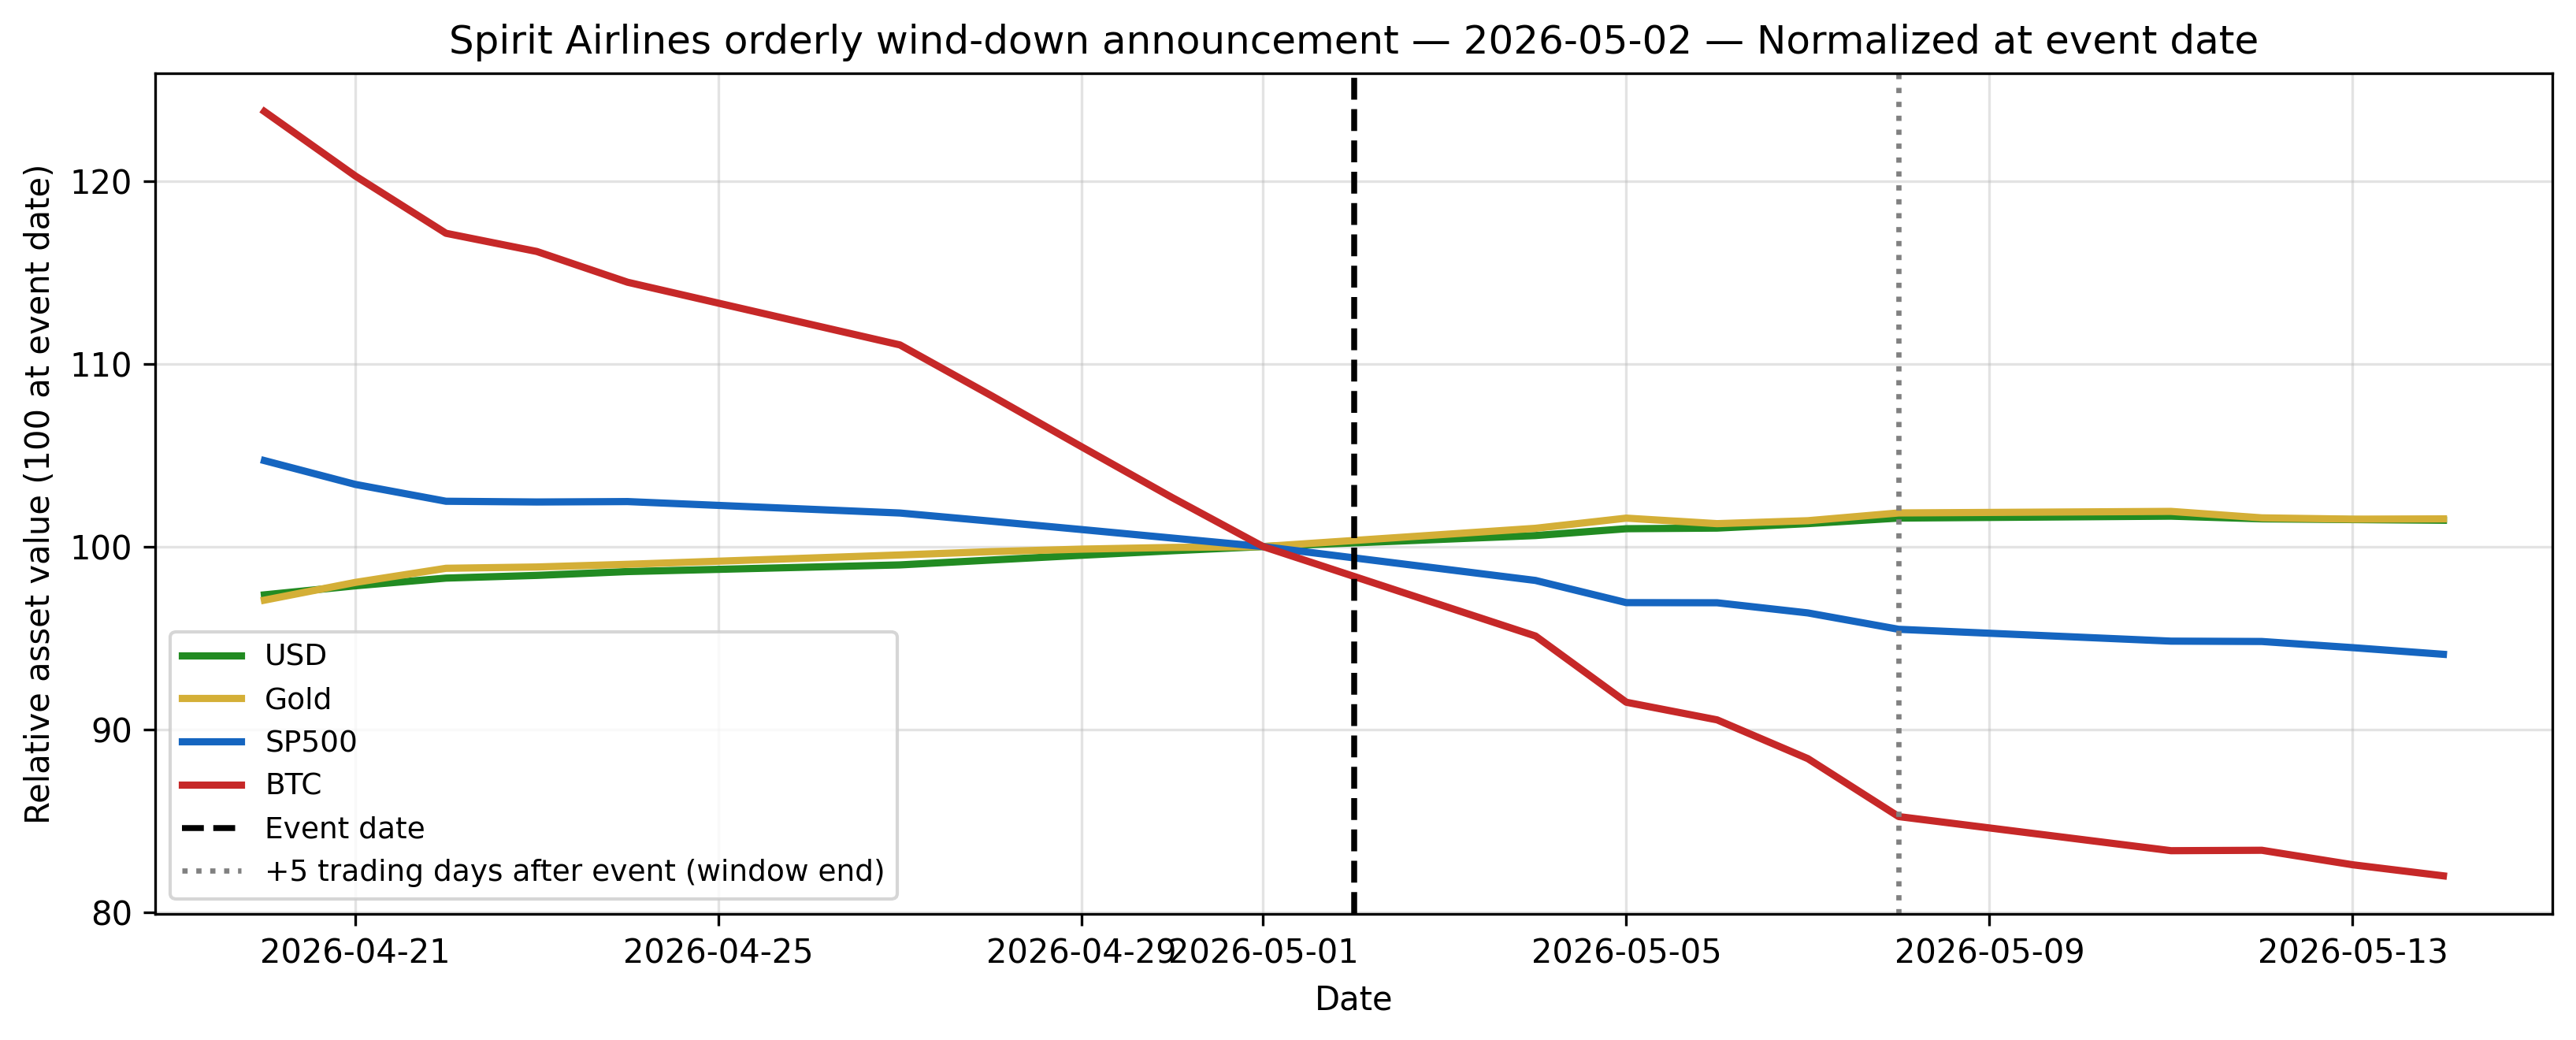

Measured shots (Qiskit Aer) → figures/poster/poster_06_EVT_9003_readout_shots.png

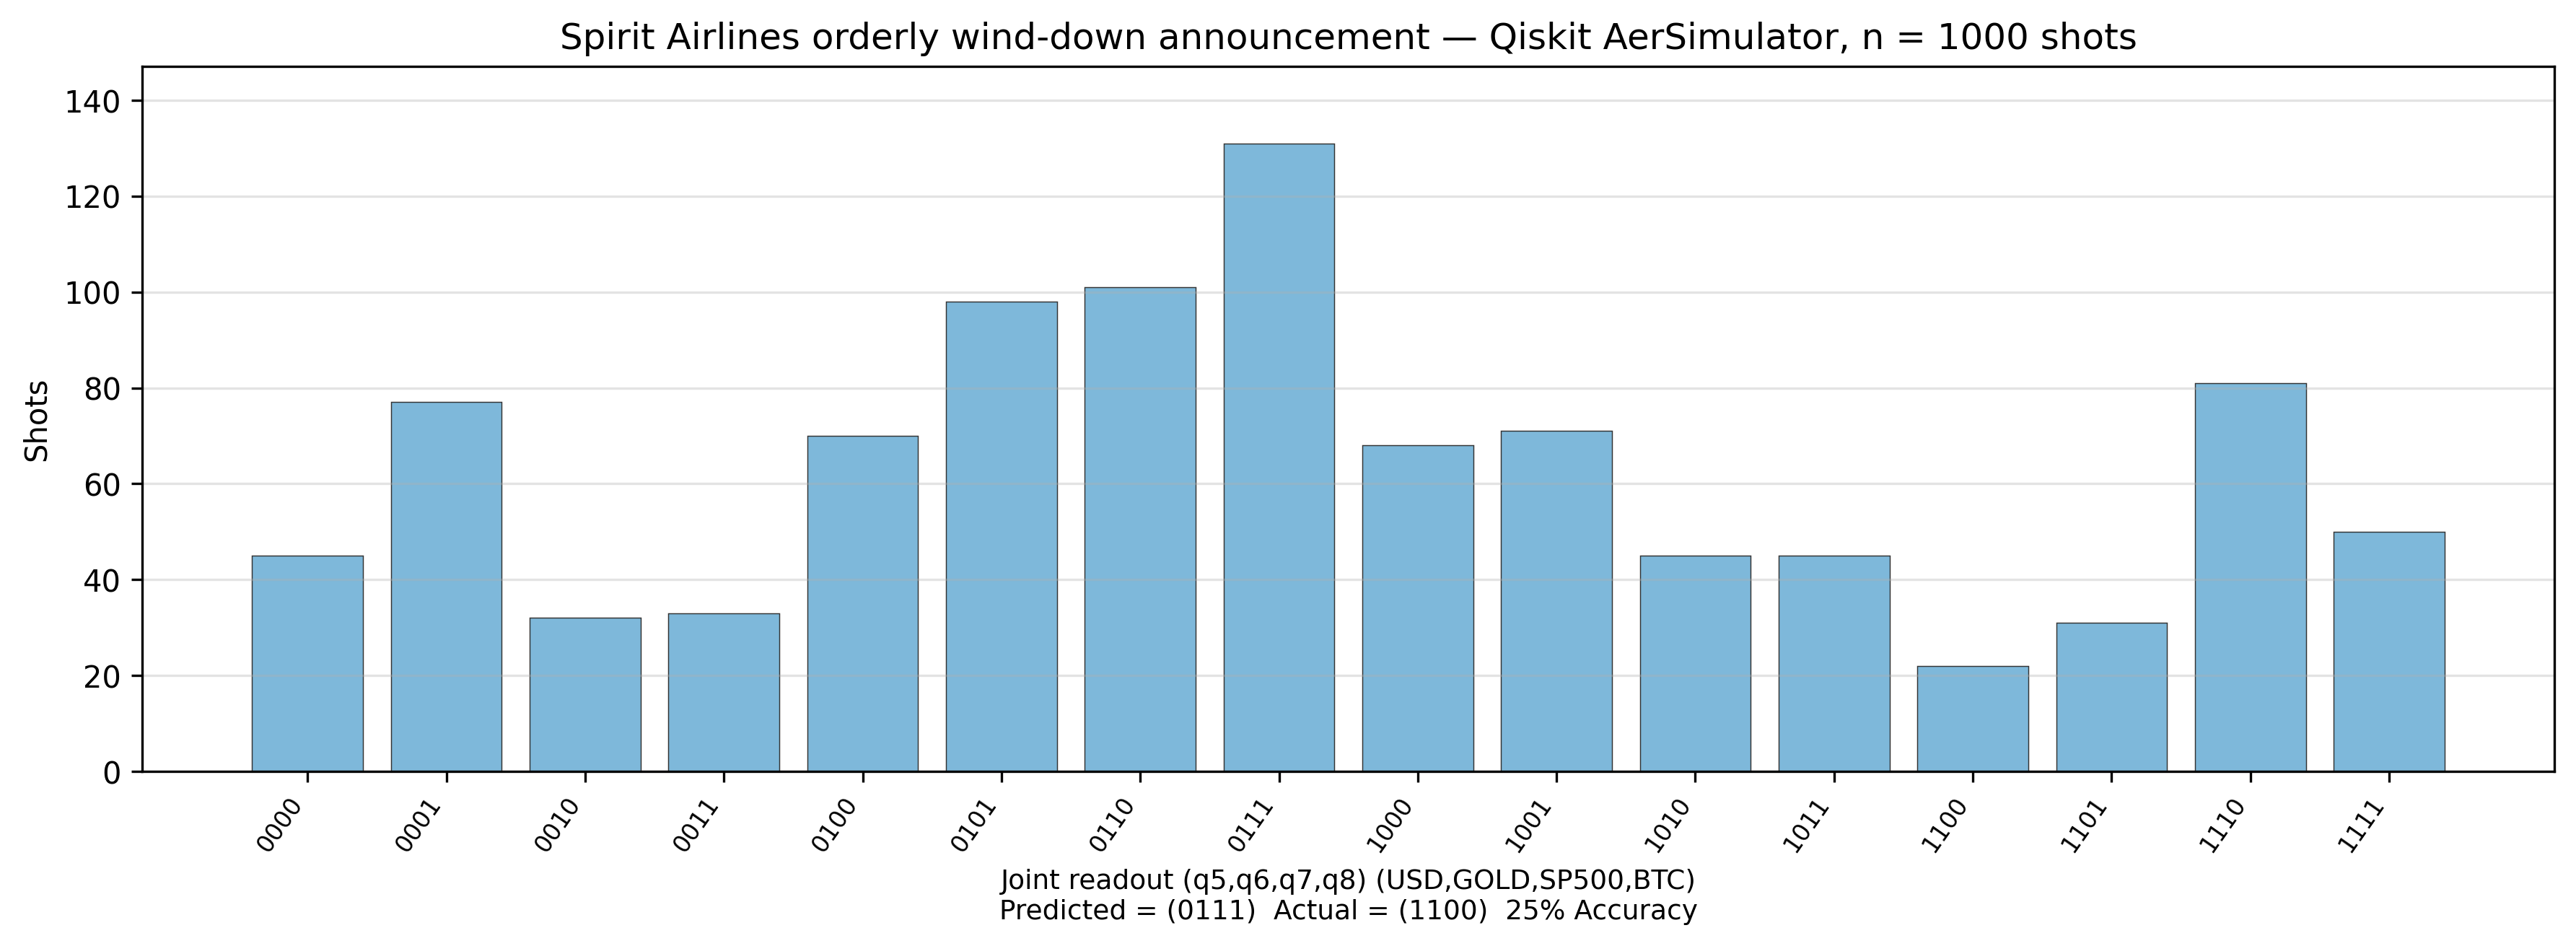

Poster export complete. poster_01…poster_03: prices; poster_04…poster_06: Qiskit measured-shots histograms (y-axis: shot counts, zoomed).

In [147]:
# =============================================================================
# CELL: Poster figures (9 PNGs) — Bloch + prices + Qiskit Aer shot histograms per holdout
# =============================================================================
# Nine PNGs under figures/poster/: poster_01..03_*_bloch.png, poster_01..03_*_prices.png, poster_04..06_*_readout_shots.png (paper figures).
# Requires: theta, num_layers from params cell; run Figure 3 cell first for `prices` (or this cell reloads it).
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_bloch_vector

from build_training_events import (
    RETURNS_PATH,
    build_labeled_event_frame,
    _load_events,
    _load_returns,
)

POSTER_DIR = ROOT / "figures" / "poster"
POSTER_DIR.mkdir(parents=True, exist_ok=True)  # poster-ready 6-panel exports
POSTER_SHOTS = 1000
POSTER_WINDOW_DAYS = 12
POSTER_DPI = 300

# Price table (same as Figure 3 cell); rebuild if this cell is run alone
if "prices" not in globals():
    _px = pd.read_csv(DATA_DIR / "asset_prices_clean.csv")  # same daily prices as Figure 3
    prices = _px.rename(
        columns={"Date": "date", "GOLD": "Gold", "SP500": "SP500", "BTC": "BTC", "USD": "USD"}
    ).copy()
    prices["date"] = pd.to_datetime(prices["date"])
    prices = prices.sort_values("date")


def _poster_nearest_price_index(date_series: pd.Series, target: pd.Timestamp) -> int:
    """Nearest trading row to a calendar date (poster price panels)."""
    return int((date_series - target).abs().idxmin())


def _aer_to_born_key(aer: str) -> str:
    """Map Aer bit order (c0..c3) to USD-Gold-SP500-BTC string."""
    return aer[3] + aer[2] + aer[1] + aer[0]


def _bloch_vec(theta: float, phi: float) -> list[float]:
    """Bloch coordinates for RY(theta) with azimuth phi (here phi=0)."""
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)
    return [x, y, z]


def _input_wire_ry_encoding_angles(features: np.ndarray) -> np.ndarray:
    """RY gate angles fed to wires q0..q4, matching quantum_market_model.build_circuit."""
    f = np.asarray(features, dtype=float).ravel()
    return np.array(
        [
            np.pi * f[0],
            (np.pi / 2.0) * f[1],
            (np.pi / 2.0) * f[2],
            (np.pi / 2.0) * f[3],
            (np.pi / 2.0) * f[4],
        ],
        dtype=float,
    )


INPUT_QUBIT_WIRE_PANELS = (
    ("q0 — Intensity qubit", "pi * f0"),
    ("q1 — Geo / macro qubit", "(pi/2) * f1"),
    ("q2 — Disaster / disruption qubit", "(pi/2) * f2"),
    ("q3 — Technology / adoption qubit", "(pi/2) * f3"),
    ("q4 — Regulation / policy qubit", "(pi/2) * f4"),
)


poster_states = [f"{i:04b}" for i in range(16)]

if "labeled_hold" not in globals():
    hold_raw = _load_events(DATA_DIR / "holdout_events.csv")  # three poster case-study events
    returns_df = _load_returns(RETURNS_PATH)  # daily returns for label windows
    labeled_hold, _ = build_labeled_event_frame(
        hold_raw,
        returns_df,
        label_horizon=LABEL_HORIZON,
        fuse_market=False,
        temporal_cutoff=None,
        enforce_temporal_cutoff=False,
    )
elif "hold_raw" not in globals():
    hold_raw = _load_events(DATA_DIR / "holdout_events.csv")  # holdout catalog (elif branch)

name_lookup = hold_raw.set_index("event_id")["event_name"].to_dict()

poster_labeled = labeled_hold.sort_values("event_id").reset_index(drop=True)

# --- Poster export loop: three holdouts → nine PNGs for the paper ---
for idx, (_, row) in enumerate(poster_labeled.iterrows(), start=1):
    eid = str(row["event_id"])
    event_name = str(name_lookup.get(eid, eid))
    event_date = pd.to_datetime(row["event_date"])
    pred_date = pd.to_datetime(row["prediction_date"])
    feats = row[FEATURE_COLS].to_numpy(dtype=float)

    display(Markdown(f"### Input qubits for {event_name}"))
    display(
        Markdown(
            "Paper-friendly Bloch spheres (left to right: q0 through q4). "
            "The PQC initializes each headline wire separately from the computational ground state with one RY in build_circuit; "
            "each subplot title names the semantic role wired to q0 intensity vs q1 thematic channels. "
            "States lie in the xz plane of each sphere (effective azimuth phi = 0) because RY uses real rotations only; "
            "intensity wire q0 uses theta = pi times the intensity score while thematic wires use theta = (pi/2) times their scores "
            "(see quantum_market_model.build_circuit), before CRY layers couple news to USD, Gold, SP500, and BTC."
        )
    )
    # (1) Bloch spheres for q0..q4 after input RY encoding.
    ry_angles = _input_wire_ry_encoding_angles(feats)
    fig_bloch, axes_bloch = plt.subplots(1, 5, figsize=(16, 4.3), subplot_kw=dict(projection="3d"))
    for qi, theta_ry in enumerate(ry_angles):
        heading, frm = INPUT_QUBIT_WIRE_PANELS[qi]
        fi = float(feats[qi])
        title = f"{heading}\nRY theta = {theta_ry:.3f} ({frm})\nscore = {fi:.3f}"
        try:
            plot_bloch_vector(
                _bloch_vec(theta_ry, 0.0),
                title=title,
                ax=axes_bloch[qi],
                font_size=11,
            )
        except TypeError:
            plot_bloch_vector(_bloch_vec(theta_ry, 0.0), title=title, ax=axes_bloch[qi])
    fig_bloch.subplots_adjust(top=0.76, bottom=0.02, left=0.02, right=0.99, wspace=0.06)
    fig_bloch.suptitle(f"Input qubits for {event_name}", fontsize=15, y=0.98)
    path_bloch = POSTER_DIR / f"poster_{idx:02d}_{eid}_bloch.png"
    fig_bloch.savefig(path_bloch, bbox_inches="tight", dpi=POSTER_DPI)
    display(Markdown(f"Bloch figure → {path_bloch.relative_to(ROOT)}"))
    display(fig_bloch)
    plt.close(fig_bloch)
    # (2) Normalized price window centered on the headline date.
    start = event_date - pd.Timedelta(days=POSTER_WINDOW_DAYS)
    end = pred_date + pd.Timedelta(days=POSTER_WINDOW_DAYS)
    window = prices[(prices["date"] >= start) & (prices["date"] <= end)].copy()
    idx_base = _poster_nearest_price_index(window["date"], event_date)
    base_row = window.loc[idx_base]
    for col in ASSET_ORDER:
        window[f"z_{col}"] = 100.0 * window[col] / base_row[col]

    fig_a, ax_a = plt.subplots(figsize=(11, 4.5), dpi=POSTER_DPI)
    for col in ASSET_ORDER:
        ax_a.plot(
            window["date"],
            window[f"z_{col}"],
            label=col,
            linewidth=2.2,
            color=ASSET_COLORS[col],
        )
    ax_a.axvline(event_date, color="black", linestyle="--", linewidth=1.8, label="Event date")
    nh = int(row.get("label_horizon_trading_days", LABEL_HORIZON))
    ax_a.axvline(
        pred_date,
        color="gray",
        linestyle=":",
        linewidth=1.6,
        label=f"+{nh} trading days after event (window end)",
    )
    date_str = event_date.strftime("%Y-%m-%d")
    ax_a.set_title(f"{event_name} — {date_str} — Normalized at event date", fontsize=15)
    ax_a.set_xlabel("Date", fontsize=14)
    ax_a.set_ylabel("Relative asset value (100 at event date)", fontsize=14)
    ax_a.tick_params(labelsize=13)
    ax_a.grid(alpha=0.35)
    ax_a.legend(loc="best", fontsize=13)
    fig_a.tight_layout()
    path_a = POSTER_DIR / f"poster_{idx:02d}_{eid}_prices.png"  # normalized price window (poster tile)
    fig_a.savefig(path_a, bbox_inches="tight")  # write poster price PNG
    display(Markdown(f"Price figure → {path_a.relative_to(ROOT)}"))
    display(fig_a)
    plt.close(fig_a)

    # (3) 1000-shot histogram over 16 joint asset bitstrings.
    qc = build_circuit(feats, theta, num_layers=num_layers, add_measurements=True)
    backend = AerSimulator()
    seed = 900 + hash(eid) % 10_000
    counts = backend.run(qc, shots=POSTER_SHOTS, seed_simulator=seed).result().get_counts()
    shot_counts = {s: 0 for s in poster_states}
    # Bin Aer counts into canonical USD-Gold-SP500-BTC keys.
    for bitstr, v in counts.items():
        if len(bitstr) != 4:
            continue
        shot_counts[_aer_to_born_key(bitstr)] += int(v)
    heights = np.array([shot_counts[s] for s in poster_states], dtype=float)
    pred_mode = max(poster_states, key=lambda s: shot_counts[s])
    actual_bits = (
        f"{int(row['usd_up'])}{int(row['gold_up'])}"
        f"{int(row['sp500_up'])}{int(row['btc_up'])}"
    )
    bit_acc = 100.0 * sum(pred_mode[i] == actual_bits[i] for i in range(4)) / 4.0
    hist_xlabel = (
        "Joint readout (q5,q6,q7,q8) (USD,GOLD,SP500,BTC)\n"
        f"Predicted = ({pred_mode})  Actual = ({actual_bits})  {bit_acc:.0f}% Accuracy"
    )

    fig_b, ax_shot = plt.subplots(figsize=(12, 5.2), dpi=POSTER_DPI)
    x = np.arange(16)
    ax_shot.bar(x, heights, color="#7eb8da", edgecolor="#333", linewidth=0.35)
    ax_shot.set_xticks(x)
    ax_shot.set_xticklabels(poster_states, rotation=55, ha="right", fontsize=13)
    ax_shot.set_ylabel("Shots", fontsize=14)
    ax_shot.set_xlabel(hist_xlabel, fontsize=14)
    ax_shot.tick_params(labelsize=13)
    ax_shot.set_title(
        f"{event_name} — Qiskit AerSimulator, n = {POSTER_SHOTS} shots",
        fontsize=15,
    )
    max_h = float(heights.max()) if heights.size else 0.0
    cap_20 = int(np.ceil(0.20 * POSTER_SHOTS))
    if max_h <= cap_20:
        ymax = min(int(np.ceil(max_h * 1.12)), cap_20)
    else:
        ymax = min(int(np.ceil(max_h * 1.08)), POSTER_SHOTS)
    ax_shot.set_ylim(0, max(ymax, 1))
    ax_shot.grid(axis="y", alpha=0.35)
    fig_b.tight_layout(rect=[0, 0.14, 1, 1])
    path_b = POSTER_DIR / f"poster_{idx + 3:02d}_{eid}_readout_shots.png"  # 1000-shot joint readout histogram
    fig_b.savefig(path_b, bbox_inches="tight")  # write poster histogram PNG
    display(Markdown(f"Measured shots (Qiskit Aer) → {path_b.relative_to(ROOT)}"))
    display(fig_b)
    plt.close(fig_b)

display(Markdown("Poster export complete. poster_01…03: Bloch inputs; poster_01…03: prices; poster_04…06: Qiskit measured-shots histograms (used in Final_Project.tex)."))


## Related notebooks

- quantum_register_correlated_markets.ipynb — original 9-qubit prototype with hand-tuned scenarios and shot demos
- Final_Project_Code_Narrative.ipynb — report-aligned supplement with the same data contract
- updated_circuit_finetuned.ipynb — beginner-friendly tour of the trained model

This notebook is the submission record for the current pipeline (200-row training set, 5-day labels, three holdouts, poster exports).


## Limitations

- Small sample and chronological split → wide confidence intervals on accuracy.  
- Hand-built event scores and toy quantum finance framing — not investment advice.  
- Simulator ideal Born probabilities; hardware noise would differ.  
- COBYLA stopped by iteration budget; better fits may need more iterations or different optimizers.
